In [4]:
import os  # Import the os module to interact with the operating system
import pandas as pd  # Import pandas for data manipulation and analysis
import numpy as np  # Import numpy for numerical operations
from scipy.stats import ranksums  # Import ranksums for Wilcoxon rank-sum test
from statsmodels.stats.multitest import multipletests  # Import for multiple testing correction
from scipy.stats import wilcoxon
# Load MPRA (Massively Parallel Reporter Assay) data
df_mpra = pd.read_csv('indexing/MPRA3_Contributor_20231108_unique_GeneName_BarcodeEnhancerPair.csv', index_col=0)

# Subset the MPRA data to exclude the last 15 rows from the first 24000 rows
df_mpra_23985 = df_mpra.iloc[0:24000-15]

# Load allele lookup table, renaming columns to 'alt' and 'ref'
df_index = pd.read_csv('indexing/ALT_REF_LookUpTable_filtered_amended_alleleOnly_20240605.csv')
df_index.columns = ['alt', 'ref']

# Define the path where Bayesian prediction files are located
path = "../THP1_machinelearning/mpra3_prediction/prediction/10kbmodels_20240809_MPRA_500bp_SNPandControl_Ns_227bpbarcodes_20240825/"

# Initialize empty DataFrames to store results
df_difference = pd.DataFrame()
df_difference_statistic = pd.DataFrame()
df_difference_statistic_converted = pd.DataFrame()
df_difference_logFC_majorminor_all= pd.DataFrame()
# Load Haploreg annotated SNP data
df_haploreg = pd.read_csv('indexing/SNP_haploreg_annotated_index_20240818_curated_annotated.csv', index_col=0)

# Initialize DataFrame to store log fold change (logFC) for major/minor alleles
df_difference_logFC_majorminor = pd.DataFrame()

# Iterate over all files in the specified directory
for f in os.listdir(path):
    if f.endswith("bayesian.csv") and not f.startswith("._"):
        # Load Bayesian prediction data
        df = pd.read_csv(path + f, sep='\t', header=None)
        
        # Reshape the data to match the dimensions of the MPRA dataset
        df = df.iloc[0:(24000-15)*2]
        data = df.values
        reshaped_data = data.reshape(1599, 1920)
        reshaped_df = pd.DataFrame(reshaped_data)
        reshaped_df.index = df_mpra_23985['enhancer_id'].unique()

        # Assign the reshaped data to a DataFrame
        df_avg_1599 = reshaped_df
        
        # Extract rows corresponding to 'alt' and 'ref' alleles
        alt = df_avg_1599.loc[df_index['alt']]
        ref = df_avg_1599.loc[df_index['ref']]
        
        # Ensure the 'alt' and 'ref' DataFrames have the same shape
        assert alt.shape == ref.shape, "Dataframes do not have the same shape"
        
        # Initialize lists to store p-values and test statistics
        p_values = []
        statistic_list = []
        
        # Perform rank-sum test for each row in 'alt' and 'ref'
        for i in range(alt.shape[0]):
            row_alt = alt.iloc[i, :]
            row_ref = ref.iloc[i, :]
            statistic, p_value = wilcoxon(row_alt, row_ref, alternative='two-sided')
            p_values.append(p_value)
            statistic_list.append(statistic)
            
        # Apply False Discovery Rate (FDR) correction to the p-values
        p_values_corrected = multipletests(p_values, alpha=0.05, method='fdr_bh')[1]

        # Create a DataFrame with the original and corrected p-values and statistics
        p_values_df = pd.DataFrame({
            'p_value': p_values,
            'fdr': p_values_corrected,
            'statistics': statistic_list
        })
        p_values_df.index = alt.index

        # Store FDR-corrected p-values and statistics in the difference DataFrames
        
        df_difference_statistic[f[0:19]] = p_values_df['statistics']
        
        # Calculate mean values for 'alt' and 'ref' alleles
        alt_mean = alt.mean(axis=1)
        ref_mean = ref.mean(axis=1)
        df_mean = pd.DataFrame([alt_mean.tolist(), ref_mean.tolist()]).T
        df_mean.index = alt_mean.index
        df_mean.columns = ['alt_atac_bayesian_mean', 'ref_atac_bayesian_mean']
        df_mean['ref_name'] = ref_mean.index
        df_mean['fdr_bayesian'] = p_values_df['fdr']
        
        # Compute log fold change (logFC) for 'ref' vs. 'alt'
        df_mean['logFC'] = np.log(df_mean['ref_atac_bayesian_mean'] / df_mean['alt_atac_bayesian_mean'])
        
        # Merge with Haploreg data to account for allele flip
        df_mean = pd.merge(df_mean, df_haploreg, left_index=True, right_index=True)
        df_mean['ranksum'] = p_values_df['statistics']
        df_mean['ranksum_converted'] = df_mean.apply(
            lambda row: -row['ranksum'] if row['REFALT_Flip'] else row['ranksum'], axis=1
        )
        # Adjust logFC for flipped alleles
        df_mean['logFC_converted'] = df_mean.apply(
            lambda row: -row['logFC'] if row['REFALT_Flip'] else row['logFC'], axis=1
        )
        
        # Filter significant results based on mean expression and FDR threshold
        df_mean_sig = df_mean[
            (
                (
                    (df_mean['logFC'] > 0.1) &
                    (df_mean['ref_atac_bayesian_mean'] >= 1)
                ) |
                (
                    (df_mean['logFC'] < -0.1) &
                    (df_mean['alt_atac_bayesian_mean'] >= 1)
                )
            ) &
            (df_mean['fdr_bayesian'] <= 0.05)
        ]

        # Create a Series where non-significant 'logFC_converted' values are set to 0

        df_difference_logFC_majorminor["ML_majormino_logFC_"+f[0:19]] = df_mean['logFC_converted'].round(2).where(df_mean.index.isin(df_mean_sig.index), '')
        df_difference_logFC_majorminor_all["ML_majormino_logFC_"+f[0:19]] = df_mean['logFC_converted']
        # If you also want to modify 'ranksum_converted' similarly, you can do:
        df_difference_statistic_converted[f[0:19]] = df_mean['ranksum_converted'].where(df_mean.index.isin(df_mean_sig.index), '')
        #df_difference["ML_FDR_"+f[0:19]] = (-np.log((p_values_df['fdr'])+np.exp(-400))).round(1).where(p_values_df.index.isin(df_mean_sig.index), '')
df_index = pd.read_csv("indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai20240916.csv",index_col = 0)
df_index = pd.merge(df_index,df_difference_logFC_majorminor.sort_index(axis=1),left_index=True,right_index=True)
df_index.to_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_20240919_2.csv')

/Users/zihengc/miniforge3/envs/notebook/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/zihengc/miniforge3/envs/notebook/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/zihengc/miniforge3/envs/notebook/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/zihengc/miniforge3/envs/notebook/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/zihengc/miniforge3/envs/notebook/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwa

In [11]:
#500bp genomic sequences
import pandas as pd
def convert_rc_sequence(df):
    # Assuming your original DataFrame is named `df`
    assert len(df) % 2 == 0, "Number of rows must be even to merge in pairs."

    # Reset index just to be safe
    df = df.reset_index(drop=True)

    # Take every even-indexed row (0, 2, 4, ...) as base
    df_even = df.iloc[::2].reset_index(drop=True)

    # Take every odd-indexed row (1, 3, 5, ...) to merge
    df_odd = df.iloc[1::2].reset_index(drop=True)

    # Rename columns in df_odd to avoid name collisions
    df_odd.columns = [f"{col}_rc" for col in df.columns]

    # Concatenate side-by-side
    df_merged = pd.concat([df_even, df_odd], axis=1)
    return df_merged

import os  # Import the os module to interact with the operating system
import pandas as pd  # Import pandas for data manipulation and analysis
import numpy as np  # Import numpy for numerical operations
from scipy.stats import ranksums  # Import ranksums for Wilcoxon rank-sum test
from statsmodels.stats.multitest import multipletests  # Import for multiple testing correction
from scipy.stats import wilcoxon

# Define the path where Bayesian prediction files are located
path = "../THP1_machinelearning/mpra3_prediction/prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences/"

# Initialize empty DataFrames to store results
df_difference = pd.DataFrame()
df_difference_statistic = pd.DataFrame()
df_difference_statistic_converted = pd.DataFrame()
df_difference_logFC_majorminor_all= pd.DataFrame()
# Load Haploreg annotated SNP data
df_haploreg = pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv', index_col=0)

# Initialize DataFrame to store log fold change (logFC) for major/minor alleles
df_difference_logFC_majorminor = pd.DataFrame()

# Iterate over all files in the specified directory
for f in os.listdir(path):
    if f.endswith("bayesian.csv"):
        # Load Bayesian prediction data
        df = pd.read_csv(path + f, sep='\t', header=None)

        data = df.values
        
        reshaped_data = convert_rc_sequence(pd.DataFrame(data))
        reshaped_df = pd.DataFrame(reshaped_data)

        # Assign the reshaped data to a DataFrame
        df_avg_1599 = reshaped_df
        
        # Extract rows corresponding to 'minor' and 'major' alleles
        major = df_avg_1599.loc[0:854]
        minor = df_avg_1599.loc[855:]
        major.index = df_haploreg.index
        minor.index = df_haploreg.index
        # Ensure the 'minor' and 'major' DataFrames have the same shape
        assert minor.shape == major.shape, "Dataframes do not have the same shape"
        
        # Initialize lists to store p-values and test statistics
        p_values = []
        statistic_list = []
        
        # Perform rank-sum test for each row in 'minor' and 'major'
        for i in range(minor.shape[0]):
            row_minor = minor.iloc[i, :]
            row_major = major.iloc[i, :]
            statistic, p_value = wilcoxon(row_minor, row_major, alternative='two-sided')
            p_values.append(p_value)
            statistic_list.append(statistic)
            
        # Apply False Discovery Rate (FDR) correction to the p-values
        p_values_corrected = multipletests(p_values, alpha=0.05, method='fdr_bh')[1]

        # Create a DataFrame with the original and corrected p-values and statistics
        p_values_df = pd.DataFrame({
            'p_value': p_values,
            'fdr': p_values_corrected,
            'statistics': statistic_list
        })
        p_values_df.index = minor.index

        df_one = pd.read_csv(path+f[:-12]+"one.csv", sep='\t', header=None)
        df_one = df_one.groupby(df_one.index // 2).mean()

        df_mean = pd.DataFrame([df_one.loc[0:854][0].tolist(), df_one.loc[855:][0].tolist()]).T
        df_mean.index = minor.index
        df_mean.columns = ['major_atac_bayesian_mean', 'minor_atac_bayesian_mean']
        df_mean['major_name'] =  df_haploreg.index
        df_mean['fdr_bayesian'] = p_values_df['fdr']
        
        #replace mean <=0
        df_mean.loc[df_mean['major_atac_bayesian_mean'] <= 0, 'major_atac_bayesian_mean'] = 0.01
        df_mean.loc[df_mean['minor_atac_bayesian_mean'] <= 0, 'minor_atac_bayesian_mean'] = 0.01
        
        # Compute log fold change (logFC) for 'major' vs. 'minor'
        df_mean['logFC'] = np.log(df_mean['major_atac_bayesian_mean'] / df_mean['minor_atac_bayesian_mean'])
         
        # Filter significant results based on mean expression and FDR threshold; filter by logFC before fliping 
        df_mean_sig = df_mean[
            (
                (
                    (df_mean['logFC'] > 0.1) &
                    (df_mean['major_atac_bayesian_mean'] >= 1)
                ) |
                (
                    (df_mean['logFC'] < -0.1) &
                    (df_mean['minor_atac_bayesian_mean'] >= 1)
                )
            ) &
            (df_mean['fdr_bayesian'] <= 0.05)
        ]

        df_difference_logFC_majorminor["ML_majorminor_logFC_genomic_"+f.split('_20240826')[0]] = df_mean['logFC'].round(2).where(df_mean.index.isin(df_mean_sig.index), '')
df_difference_logFC_majorminor = df_difference_logFC_majorminor.loc[:,~df_difference_logFC_majorminor.columns.str.contains("THP1_LPSIFNGvsIFNG|THP1_LPSIFNGvsNaive")
]

df_difference_logFC_majorminor
df_index = pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv', index_col=0) 
df_index = pd.merge(df_index,df_difference_logFC_majorminor.sort_index(axis=1),left_index=True,right_index=True)
df_index.to_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_20250324.csv')

In [13]:
#500bp genomic sequences
import pandas as pd
def convert_rc_sequence(df):
    # Assuming your original DataFrame is named `df`
    assert len(df) % 2 == 0, "Number of rows must be even to merge in pairs."

    # Reset index just to be safe
    df = df.reset_index(drop=True)

    # Take every even-indexed row (0, 2, 4, ...) as base
    df_even = df.iloc[::2].reset_index(drop=True)

    # Take every odd-indexed row (1, 3, 5, ...) to merge
    df_odd = df.iloc[1::2].reset_index(drop=True)

    # Rename columns in df_odd to avoid name collisions
    df_odd.columns = [f"{col}_rc" for col in df.columns]

    # Concatenate side-by-side
    df_merged = pd.concat([df_even, df_odd], axis=1)
    return df_merged

import os  # Import the os module to interact with the operating system
import pandas as pd  # Import pandas for data manipulation and analysis
import numpy as np  # Import numpy for numerical operations
from scipy.stats import ranksums  # Import ranksums for Wilcoxon rank-sum test
from statsmodels.stats.multitest import multipletests  # Import for multiple testing correction
from scipy.stats import wilcoxon

# Define the path where Bayesian prediction files are located
path = "../THP1_machinelearning/mpra3_prediction/prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences/"

# Initialize empty DataFrames to store results
df_difference = pd.DataFrame()
df_difference_statistic = pd.DataFrame()
df_difference_statistic_converted = pd.DataFrame()
df_difference_diff_majorminor_all= pd.DataFrame()
# Load Haploreg annotated SNP data
df_haploreg = pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv', index_col=0)

# Initialize DataFrame to store log fold change (diff) for major/minor alleles
df_difference_diff_majorminor = pd.DataFrame()

# Iterate over all files in the specified directory
for f in os.listdir(path):
    if f.endswith("bayesian.csv"):
        # Load Bayesian prediction data
        df = pd.read_csv(path + f, sep='\t', header=None)

        data = df.values
        
        reshaped_data = convert_rc_sequence(pd.DataFrame(data))
        reshaped_df = pd.DataFrame(reshaped_data)

        # Assign the reshaped data to a DataFrame
        df_avg_1599 = reshaped_df
        
        # Extract rows corresponding to 'minor' and 'major' alleles
        major = df_avg_1599.loc[0:854]
        minor = df_avg_1599.loc[855:]
        major.index = df_haploreg.index
        minor.index = df_haploreg.index
        # Ensure the 'minor' and 'major' DataFrames have the same shape
        assert minor.shape == major.shape, "Dataframes do not have the same shape"
        
        # Initialize lists to store p-values and test statistics
        p_values = []
        statistic_list = []
        
        # Perform rank-sum test for each row in 'minor' and 'major'
        for i in range(minor.shape[0]):
            row_minor = minor.iloc[i, :]
            row_major = major.iloc[i, :]
            statistic, p_value = wilcoxon(row_minor, row_major, alternative='two-sided')
            p_values.append(p_value)
            statistic_list.append(statistic)
            
        # Apply False Discovery Rate (FDR) correction to the p-values
        p_values_corrected = multipletests(p_values, alpha=0.05, method='fdr_bh')[1]

        # Create a DataFrame with the original and corrected p-values and statistics
        p_values_df = pd.DataFrame({
            'p_value': p_values,
            'fdr': p_values_corrected,
            'statistics': statistic_list
        })
        p_values_df.index = minor.index

        df_one = pd.read_csv(path+f[:-12]+"one.csv", sep='\t', header=None)
        df_one = df_one.groupby(df_one.index // 2).mean()

        df_mean = pd.DataFrame([df_one.loc[0:854][0].tolist(), df_one.loc[855:][0].tolist()]).T
        df_mean.index = minor.index
        df_mean.columns = ['major_atac_bayesian_mean', 'minor_atac_bayesian_mean']
        df_mean['major_name'] =  df_haploreg.index
        df_mean['fdr_bayesian'] = p_values_df['fdr']
        
        #replace mean <=0
        df_mean.loc[df_mean['major_atac_bayesian_mean'] <= 0, 'major_atac_bayesian_mean'] = 0.01
        df_mean.loc[df_mean['minor_atac_bayesian_mean'] <= 0, 'minor_atac_bayesian_mean'] = 0.01
        
        # Compute log fold change (diff) for 'major' vs. 'minor'
        df_mean['diff'] = df_mean['major_atac_bayesian_mean'] - df_mean['minor_atac_bayesian_mean']
         
        # Filter significant results based on mean expression and FDR threshold; filter by diff before fliping 
        df_mean_sig = df_mean[
            (
                (
                    (df_mean['diff'] > 0.5) &
                    (df_mean['major_atac_bayesian_mean'] >= 1)
                ) |
                (
                    (df_mean['diff'] < -0.5) &
                    (df_mean['minor_atac_bayesian_mean'] >= 1)
                )
            ) &
            (df_mean['fdr_bayesian'] <= 0.05)
        ]

        df_difference_diff_majorminor["ML_majorminor_diff_genomic_"+f.split('_20240826')[0]] = df_mean['diff'].round(2).where(df_mean.index.isin(df_mean_sig.index), '')
df_difference_diff_majorminor = df_difference_diff_majorminor.loc[:,~df_difference_diff_majorminor.columns.str.contains("THP1_LPSIFNGvsIFNG|THP1_LPSIFNGvsNaive")
]

df_index = pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_20250324.csv', index_col=0) 
df_index = pd.merge(df_index,df_difference_diff_majorminor.sort_index(axis=1),left_index=True,right_index=True)
df_index.to_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_20250608.csv')


# HEATMAP

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_allele_differences=pd.DataFrame()
df_allele_fdr=pd.DataFrame()
for f in os.listdir('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/'):
    if f.endswith('.csv'):
        print(f)
        df_tmp= pd.read_csv(f"allele_differences_withoutcontrol/20240817_allele_only_for_plotting/{f}", index_col=0)
        #df_tmp.loc[df_tmp['fdr'] <= 0.05, 'logFC_converted'] = 0
        df_allele_differences[f[31:-15]+"_MPRA"]= df_tmp['logFC_converted'] 
        df_allele_fdr[f[31:-15]+"_MPRA"]= df_tmp['fdr'] 
#df_mpra_ml_logFC = pd.merge(df_allele_differences,df_difference_logFC_majorminor_all,left_index=True,right_index=True).dropna()
############################################################################### fillna for convenience
import pandas as pd

# Merging DataFrames
df_mpra_ml_logFC = pd.merge(df_allele_differences, df_difference_logFC_majorminor_all, left_index=True, right_index=True)

# Calculating the mean of each column in the merged DataFrame
column_means = df_mpra_ml_logFC.mean()

# Filling missing values with the corresponding mean of each column
df_mpra_ml_logFC = df_mpra_ml_logFC.fillna(column_means)
#################################################################################
df = df_mpra_ml_logFC

normalized_mpra_ml = (df_mpra_ml_logFC/df_mpra_ml_logFC.std()).drop(['HEK293T_MPRA','GutR1R2merged20240404_LI_MPRA','GutR1R2merged20240404_SI_MPRA','THP1Monocyte_MPRA','THP1Macrophage_MPRA','HMC3THP1mac_CommonEffects_MPRA','BrainR1R2merged20240404_MPRA','HMC3_MPRA','GutR1R2merged20240404_MPRA'],axis=1)#,'GutR1R2merged20240404_SI_MPRA','GutR1R2merged20240404_LI_MPRA'
normalized_mpra_ml = normalized_mpra_ml.iloc[:,normalized_mpra_ml.columns.str.contains('MPRA')]

annotated_20240616_comparative_HMC3_IFNB_alleleOnly.csv
annotated_20240814_comparative_GutR1R2merged20240404_alleleOnly.csv
annotated_20240812_comparative_HMC3_alleleOnly.csv
annotated_20240719_comparative_THP1Monocyte_alleleOnly.csv
annotated_20240719_comparative_HEK293T_alleleOnly.csv
annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv
annotated_20240814_comparative_GutR1R2merged20240404_LI_alleleOnly.csv
annotated_20240715_comparative_HMC3_IFNG_alleleOnly.csv
annotated_20240616_comparative_THP1_IFNB_alleleOnly.csv
annotated_20240814_comparative_GutR1R2merged20240404_SI_alleleOnly.csv
annotated_20240616_comparative_THP1_IFNG_alleleOnly.csv
annotated_20240814_comparative_HMC3THP1mac_CommonEffects_alleleOnly.csv
annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv
annotated_20240616_comparative_BrainR1R2merged20240404_Cortex_alleleOnly.csv
annotated_20240616_comparative_BrainR1R2merged20240404_Hippocampus_alleleOnly.csv
annotated_20240616_comparative_BrainR1R2

In [ ]:
import os
import glob
import pandas as pd

# Set your folder path here:
folder_path = "allele_differences_with_MAD"

# Define your cell types. The string must match the prefix of your filenames.
cell_types = [
    "HMC3",
    "THP1Macrophage",
    "BrainR1R2merged20240404",
]

# Create a dictionary to hold the combined DataFrame for each cell type
combined_dfs = {}

for cell_type in cell_types:
    # Construct a glob pattern to match the files for this cell type
    pattern = os.path.join(folder_path, f"{cell_type}*.csv")
    matched_files = glob.glob(pattern)
    
    all_dfs = []
    for file_path in matched_files:
        # Use the first column as the DataFrame index
        df = pd.read_csv(file_path, index_col=0)
        
        # Filter: keep rows where pval.mad.minor < 0.05 OR pval.mad.major < 0.05
        df = df[(df["pval.mad.minor"] <= 0.1) | (df["pval.mad.major"] <= 0.1)]
        
        # Create a new column with the file name
        df["source_file"] = os.path.basename(file_path)
        
        all_dfs.append(df)
    
    # Combine all dataframes for this cell type
    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=False)  # keep index if desired
    else:
        combined_df = pd.DataFrame()
    
    # Store in the dictionary
    combined_dfs[cell_type] = combined_df


alllele_and_mad_index = set(combined_dfs["BrainR1R2merged20240404"].index.tolist()+combined_dfs["HMC3"].index.tolist()+combined_dfs["THP1Macrophage"].index.tolist())


# KMEANS

/tmp/ipykernel_139916/876990544.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaled_data["Cluster"] = clusters


Silhouette Score: 0.3112889237152663


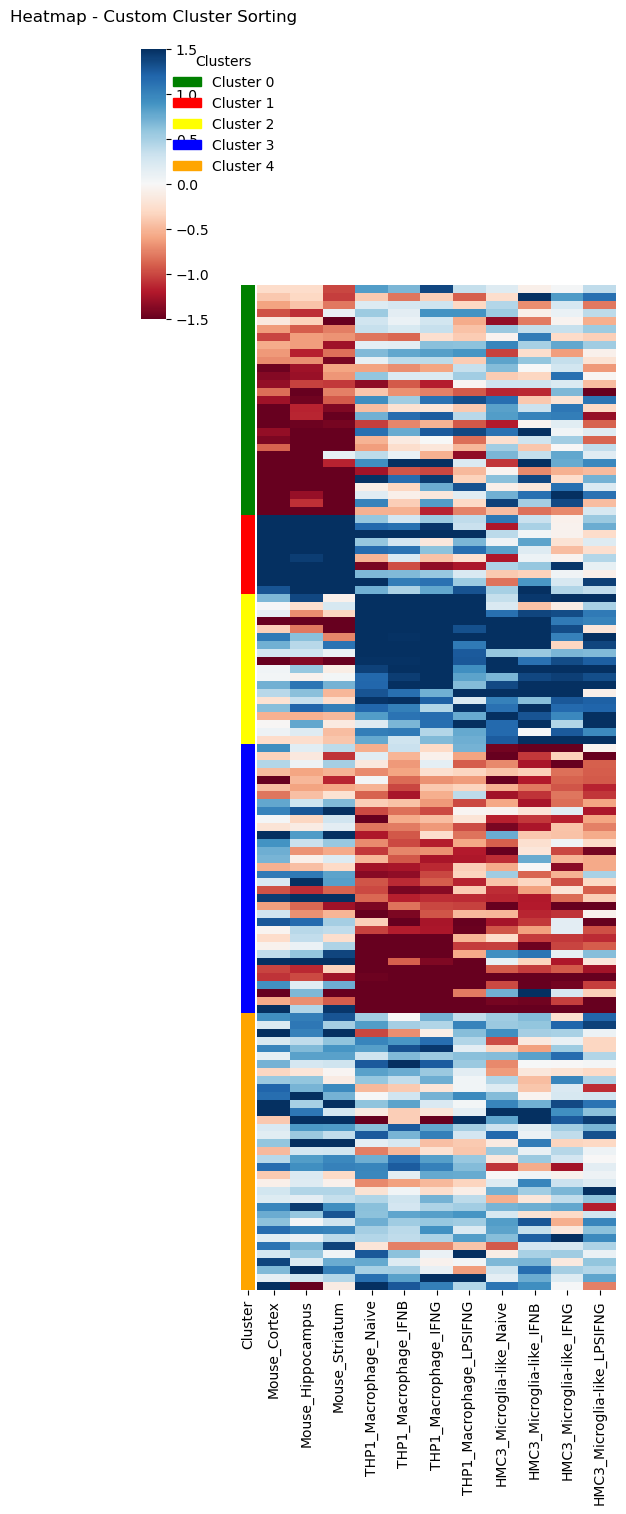

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ------------------------------------------------------------------------
# 1) Load or define your normalized data (normalized_mpra_ml), 
#    then filter the rows of interest
# ------------------------------------------------------------------------
# Example:
# normalized_mpra_ml = pd.read_csv("path_to_your_data.csv", index_col=0)
# allelele_and_mad_index might be a list of indices or a Series of booleans
# significant_variants might be used similarly
# For demonstration, we assume you already have normalized_mpra_ml 
# and allelele_and_mad_index in the environment.

scaled_data = normalized_mpra_ml[normalized_mpra_ml.index.isin(alllele_and_mad_index)]

# Optionally, if you want to scale these features, apply StandardScaler:
# scaler = StandardScaler()
# scaled_data_array = scaler.fit_transform(scaled_data)
# scaled_data = pd.DataFrame(scaled_data_array, index=scaled_data.index, columns=scaled_data.columns)

# ------------------------------------------------------------------------
# 2) K-means clustering
# ------------------------------------------------------------------------
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
scaled_data["Cluster"] = clusters

# ------------------------------------------------------------------------
# 3) Silhouette score
# ------------------------------------------------------------------------
silhouette_avg = silhouette_score(scaled_data, clusters)
print(f"Silhouette Score: {silhouette_avg}")

# ------------------------------------------------------------------------
# 4) Make a copy for sorting and exporting
# ------------------------------------------------------------------------
df_for_csv = scaled_data.copy()

# Columns of interest for sorting
brain_cols = [
    "BrainR1R2merged20240404_Cortex_MPRA",
    "BrainR1R2merged20240404_Hippocampus_MPRA",
    "BrainR1R2merged20240404_Striatum_MPRA"
]
thp1_cols = [
    "THP1_LPSIFNG_MPRA",
    "THP1_Naive_MPRA",
    "THP1_IFNB_MPRA",
    "THP1_IFNG_MPRA"
]

# ------------------------------------------------------------------------
# 5) Custom sorting by cluster
# ------------------------------------------------------------------------
def sort_by_mean(df, columns):
    # Helper function: add mean column, sort ascending, drop the helper column
    df["temp_sort_key"] = df[columns].mean(axis=1)
    df.sort_values("temp_sort_key", ascending=False, inplace=True)
    df.drop(columns="temp_sort_key", inplace=True)
    return df


sorted_dfs = []

# Sort cluster 0 and 1 by the mean of the brain columns
for c in [0, 1]:
    sub = df_for_csv[df_for_csv["Cluster"] == c].copy()
    sub = sort_by_mean(sub, brain_cols)
    sorted_dfs.append(sub)

# Sort cluster 2 and 3 by the mean of the THP1 columns
for c in [2, 3]:
    sub = df_for_csv[df_for_csv["Cluster"] == c].copy()
    sub = sort_by_mean(sub, thp1_cols)
    sorted_dfs.append(sub)

# For cluster 4, keep as is (or define a sorting rule if you wish)
if 4 in df_for_csv["Cluster"].unique():
    sub = df_for_csv[df_for_csv["Cluster"] == 4].copy()
    sorted_dfs.append(sub)

# Concatenate in ascending cluster order: 0,1,2,3,4
df_sorted = pd.concat(sorted_dfs, axis=0)

# ------------------------------------------------------------------------
# 6) Write out the sorted DataFrame to CSV
# ------------------------------------------------------------------------
df_sorted.to_csv("allele_clustering/normalized_snp_ml_cluster_fixed_20250324_5cluster_customsort.csv")

# ------------------------------------------------------------------------
# 7) Plot a clustermap preserving the custom-sorted order
# ------------------------------------------------------------------------
cluster_colors = {0: 'green', 1: 'red', 2: 'yellow', 3: 'blue', 4: 'orange'}
row_colors = df_sorted["Cluster"].map(cluster_colors)

# Drop 'Cluster' from the values we plot
df_for_plot = df_sorted.drop(columns="Cluster")
df_for_plot=df_for_plot[['BrainR1R2merged20240404_Cortex_MPRA', 'BrainR1R2merged20240404_Hippocampus_MPRA','BrainR1R2merged20240404_Striatum_MPRA',
'THP1_Naive_MPRA','THP1_IFNB_MPRA', 'THP1_IFNG_MPRA', 'THP1_LPSIFNG_MPRA','HMC3_Naive_MPRA', 'HMC3_IFNB_MPRA',  'HMC3_IFNG_MPRA', 'HMC3_LPSIFNG_MPRA',  ]]
df_for_plot.columns = ['Mouse_Cortex','Mouse_Hippocampus','Mouse_Striatum','THP1_Macrophage_Naive','THP1_Macrophage_IFNB','THP1_Macrophage_IFNG','THP1_Macrophage_LPSIFNG',
                      'HMC3_Microglia-like_Naive','HMC3_Microglia-like_IFNB','HMC3_Microglia-like_IFNG','HMC3_Microglia-like_LPSIFNG']
# Create the clustermap
g = sns.clustermap(
    df_for_plot,
    cmap="RdBu",           # or another palette
    yticklabels=False,     # avoid large y-axis labels if too many rows
    xticklabels=True,      # show column labels
    row_cluster=False, 
    col_cluster= False,    # preserve the manual sort order
    vmin=-1.5,
    vmax=1.5,
    row_colors=row_colors, # color bars along the rows
    figsize=(5, 15)
)

# Build a legend for the cluster colors
handles = [
    mpatches.Patch(color=color, label=f"Cluster {c}")
    for c, color in cluster_colors.items()
]
plt.legend(
    handles=handles,
    title="Clusters",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.,
    frameon=False
)

plt.title("Heatmap - Custom Cluster Sorting", pad=20)
plt.savefig('Heatmap_Hierarchical_Clustering_5clusters_mpra.pdf', dpi=300)
plt.show()


# Fixed

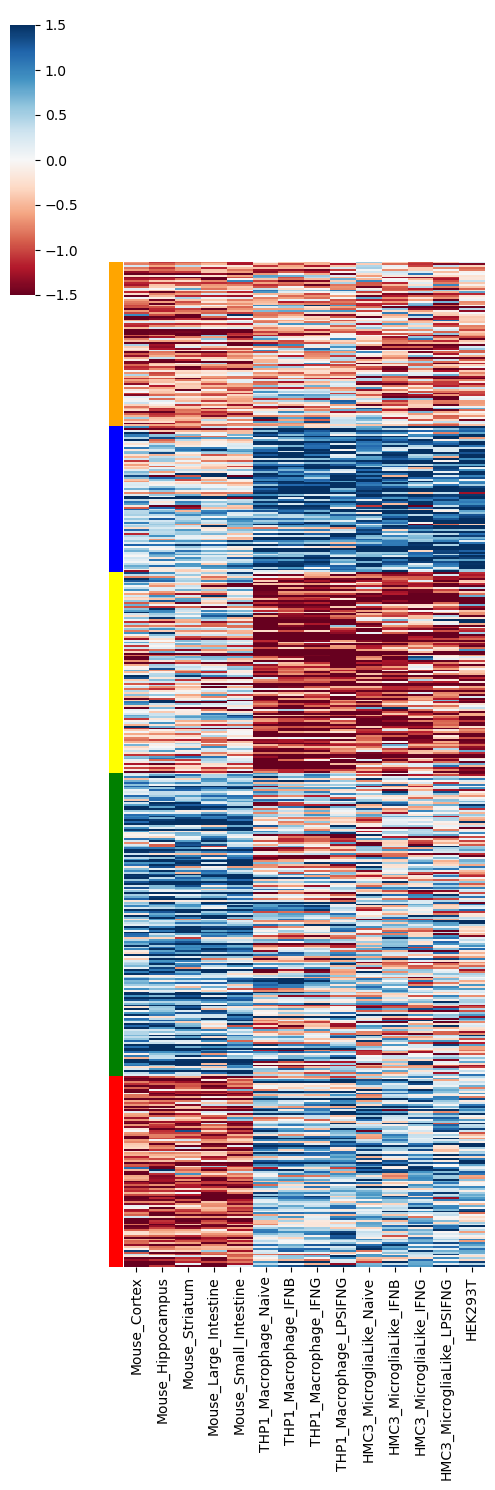

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches

# Load data
df_cluster = pd.read_csv("allele_clustering/normalized_snp_mpra_cluster_20241102_5cluster_fixed_noGutmerged.csv", index_col=0)
significant_variants = df_allele_fdr[(df_allele_fdr['THP1Macrophage_MPRA']<=0.05)|(df_allele_fdr['BrainR1R2merged20240404_MPRA']<=0.05)|(df_allele_fdr['HMC3_MPRA']<=0.05)]

df_cluster = df_cluster.loc[significant_variants.index]

clusters = df_cluster['Cluster']

# Define colors for each cluster
cluster_colors = {1: 'red', 0: 'green', 2: 'yellow', 3: 'blue', 4: 'orange'}

# Map the colors
row_colors = clusters.map(cluster_colors)

# Reorder the DataFrame according to the new cluster order
desired_order = [4,3,2,0,1]

mapping = {cluster: i for i, cluster in enumerate(desired_order)}
key = df_cluster['Cluster'].map(mapping)
df_cluster = df_cluster.iloc[key.argsort()]

# Update row_colors to match the new order
row_colors = df_cluster['Cluster'].map(cluster_colors)

# Drop the 'Cluster' column if you don't want it in the heatmap
df_cluster = df_cluster.drop(columns='Cluster', axis=1)
df_cluster=df_cluster[['BrainR1R2merged20240404_Cortex_MPRA', 'BrainR1R2merged20240404_Hippocampus_MPRA','BrainR1R2merged20240404_Striatum_MPRA','GutR1R2merged20240404_LI_MPRA','GutR1R2merged20240404_SI_MPRA',
'THP1_Naive_MPRA','THP1_IFNB_MPRA', 'THP1_IFNG_MPRA', 'THP1_LPSIFNG_MPRA','HMC3_Naive_MPRA', 'HMC3_IFNB_MPRA',  'HMC3_IFNG_MPRA', 'HMC3_LPSIFNG_MPRA',  'HEK293T_MPRA',]]
df_cluster.columns = ['Mouse_Cortex','Mouse_Hippocampus','Mouse_Striatum','Mouse_Large_Intestine','Mouse_Small_Intestine','THP1_Macrophage_Naive','THP1_Macrophage_IFNB','THP1_Macrophage_IFNG','THP1_Macrophage_LPSIFNG',
                      'HMC3_MicrogliaLike_Naive','HMC3_MicrogliaLike_IFNB','HMC3_MicrogliaLike_IFNG','HMC3_MicrogliaLike_LPSIFNG','HEK293T']
# Create the clustermap
g = sns.clustermap(
    df_cluster,
    cmap='RdBu',
    yticklabels=False,
    xticklabels=True,
    row_cluster=False,  # Since the data is pre-ordered
    col_cluster=False,  # Since the data is pre-ordered
    vmin=-1.5,
    vmax=1.5,
    row_colors=row_colors.tolist(),  # Ensure the row colors align with the sorted data
    figsize=(5, 15)
)

# Create legend handles
handles = [mpatches.Patch(color=color, label=f'Cluster {cluster}')
           for cluster, color in cluster_colors.items()]

# Add the legend to the right of the clustermap
#plt.legend(
#    handles=handles,
#    title='Clusters',
#    bbox_to_anchor=(1.05, 1),
#    loc='upper left',
#    borderaxespad=0.,
#    frameon=False
#)

# Add a title to the clustermap
#plt.title('Heatmap with Hierarchical Clustering', pad=20)
df_cluster.to_csv('allele_clustering/normalized_snp_mpra_cluster_fixed_20241202_5cluster.csv')
plt.savefig('Heatmap_Hierarchical_Clustering_5clusters_reordered.pdf', dpi=300)
# Show the plot
plt.show()


# ML

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_allele_differences=pd.DataFrame()
for f in os.listdir('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/'):
    if f.endswith('.csv'):
        df_tmp= pd.read_csv(f"allele_differences_withoutcontrol/20240817_allele_only_for_plotting/{f}", index_col=0)
        #df_tmp.loc[df_tmp['fdr'] <= 0.05, 'logFC_converted'] = 0
        df_allele_differences[f[31:-15]+"_MPRA"]= df_tmp['logFC_converted'] 
#df_mpra_ml_logFC = pd.merge(df_allele_differences,df_difference_logFC_majorminor_all,left_index=True,right_index=True).dropna()
############################################################################### fillna for convenience
import pandas as pd

# Merging DataFrames
df_mpra_ml_logFC = pd.merge(df_allele_differences, df_difference_logFC_majorminor_all, left_index=True, right_index=True)

# Calculating the mean of each column in the merged DataFrame
column_means = df_mpra_ml_logFC.mean()

# Filling missing values with the corresponding mean of each column
df_mpra_ml_logFC = df_mpra_ml_logFC.fillna(column_means)
#################################################################################
df = df_mpra_ml_logFC

normalized_mpra_ml = (df_mpra_ml_logFC/df_mpra_ml_logFC.std()).drop(['ML_majormino_logFC_THP1_LPSIFNGvsIFNG_','ML_majormino_logFC_THP1_LPSIFNGvsIFNG_','THP1Monocyte_MPRA','THP1Macrophage_al_MPRA','THP1Macrophage_MPRA','HMC3THP1mac_CommonEffects_MPRA','BrainR1R2merged20240404_MPRA','HMC3_MPRA'],axis=1)
normalized_mpra_ml = normalized_mpra_ml.iloc[:,normalized_mpra_ml.columns.str.contains('ML')]
normalized_mpra_ml.columns

Index(['ML_majormino_logFC_THP1_IFNG-Calvin_20',
       'ML_majormino_logFC_HEK293_ATAC_high_de',
       'ML_majormino_logFC_HEK293T_ATAC_202408',
       'ML_majormino_logFC_THP1_IFNB-Calvin_20',
       'ML_majormino_logFC_THP1_Naive-Calvin_2',
       'ML_majormino_logFC_Mouse_Striatum_AgeB',
       'ML_majormino_logFC_Mouse_Cortex_AgeB-m',
       'ML_majormino_logFC_THP1_LPSIFNG-Calvin',
       'ML_majormino_logFC_THP1_monocyte0729_2',
       'ML_majormino_logFC_Mouse_Cortex_AgeC-m',
       'ML_majormino_logFC_Mouse_Striatum_AgeC',
       'ML_majormino_logFC_THP1_LPSIFNGvsNaive',
       'ML_majormino_logFC_WTC11_resting_20241',
       'ML_majormino_logFC_WTC11_IFNB_20241106',
       'ML_majormino_logFC_H1_resting_20241106',
       'ML_majormino_logFC_H1_IFNB_20241106_MP'],
      dtype='object')

In [7]:
from sklearn.cluster import AgglomerativeClustering

scaled_data = normalized_mpra_ml

# Assuming 'scaled_data' is your DataFrame without the 'Cluster' column
agglomerative = AgglomerativeClustering(n_clusters=5)
clusters = agglomerative.fit_predict(scaled_data)

scaled_data['Cluster'] = clusters


from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(scaled_data, clusters)
print(f'Silhouette Score: {silhouette_avg}')

Silhouette Score: 0.3363903164760658


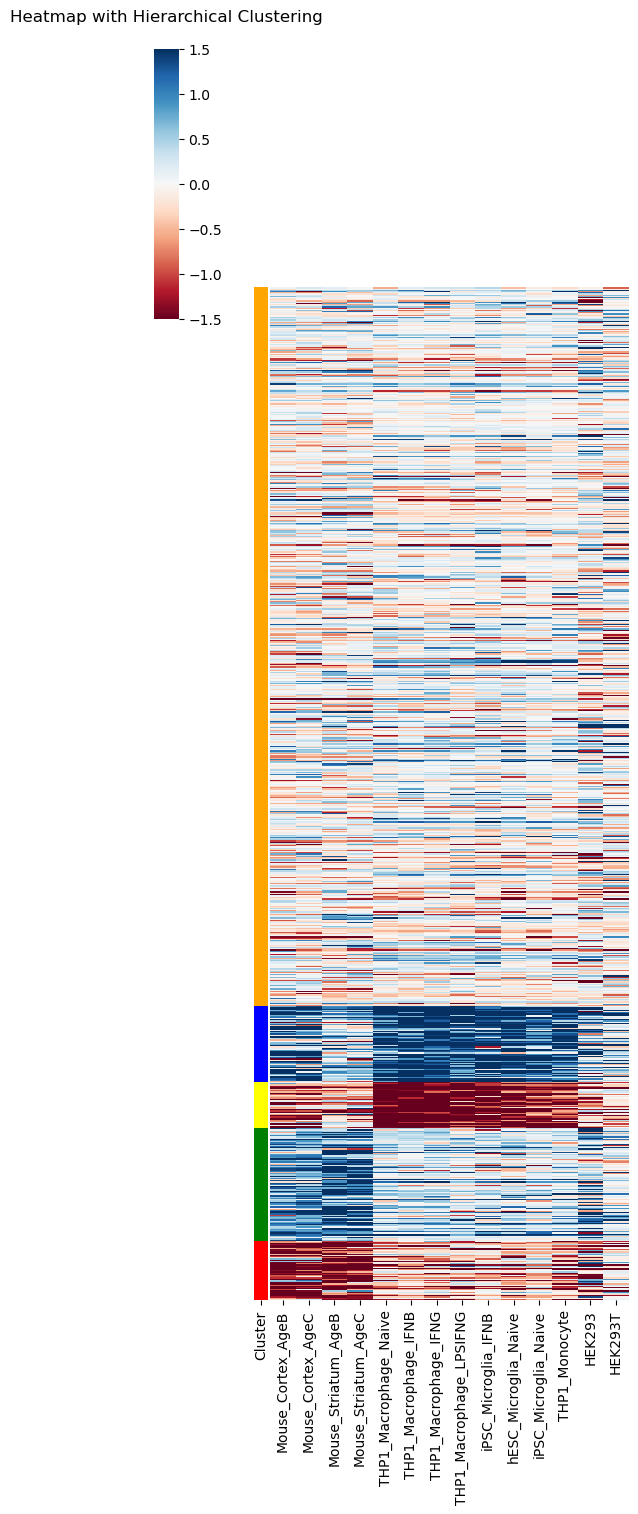

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches

# Assuming 'scaled_data' is your DataFrame with a 'Cluster' column
# sorted by 'Cluster'
#df_cluster = scaled_data.sort_values('Cluster')
df_cluster = pd.read_csv("allele_clustering/normalized_snp_ml_cluster_20241102_5cluster_fixed.csv",index_col=0)
df_cluster = pd.concat([df_cluster,scaled_data.sort_values('Cluster')[[       'ML_majormino_logFC_WTC11_resting_20241',
       'ML_majormino_logFC_WTC11_IFNB_20241106',
       'ML_majormino_logFC_H1_resting_20241106',
       'ML_majormino_logFC_H1_IFNB_20241106_MP']]],axis=1)
# Define colors for each cluster
cluster_colors = {0: 'orange', 1: 'blue', 2: 'yellow', 3: 'green', 4: 'red',5: 'purple'}
row_colors = df_cluster['Cluster'].map(cluster_colors)

# Drop the 'Cluster' column if you don't want it in the heatmap
df_cluster = df_cluster.drop(columns='Cluster', axis=1)[[
           'ML_majormino_logFC_Mouse_Cortex_AgeB-m',
           'ML_majormino_logFC_Mouse_Cortex_AgeC-m',
           'ML_majormino_logFC_Mouse_Striatum_AgeB',
           'ML_majormino_logFC_Mouse_Striatum_AgeC',
           'ML_majormino_logFC_THP1_Naive-Calvin_2',
           'ML_majormino_logFC_THP1_IFNB-Calvin_20',
           'ML_majormino_logFC_THP1_IFNG-Calvin_20',
           'ML_majormino_logFC_THP1_LPSIFNG-Calvin',
           'ML_majormino_logFC_WTC11_IFNB_20241106',
           'ML_majormino_logFC_H1_resting_20241106',
           'ML_majormino_logFC_WTC11_resting_20241',
 #         'ML_majormino_logFC_H1_IFNB_20241106_MP',
           'ML_majormino_logFC_THP1_monocyte0729_2',
           'ML_majormino_logFC_HEK293_ATAC_high_de',
           'ML_majormino_logFC_HEK293T_ATAC_202408',
]]
df_cluster.columns = ['Mouse_Cortex_AgeB',
                      'Mouse_Cortex_AgeC',
                      'Mouse_Striatum_AgeB',
                      'Mouse_Striatum_AgeC',
                      'THP1_Macrophage_Naive',
                      'THP1_Macrophage_IFNB',
                      'THP1_Macrophage_IFNG',
                      'THP1_Macrophage_LPSIFNG',
                      'iPSC_Microglia_IFNB',
                      'hESC_Microglia_Naive',
                      'iPSC_Microglia_Naive',
                      'THP1_Monocyte',
                      'HEK293',
                      'HEK293T'
                      ]
# Create the clustermap
g = sns.clustermap(
    df_cluster,
    cmap='RdBu',
    yticklabels=False,
    xticklabels=True,
    row_cluster=False,
    col_cluster=False,
    vmin=-1.5,
    vmax=1.5,
    row_colors=row_colors,
    figsize=(5, 15)  # Adjust the size as needed
)

# Create legend handles
handles = [mpatches.Patch(color=color, label=f'Cluster {cluster}') 
           for cluster, color in cluster_colors.items()]

# Add the legend to the right of the clustermap
#plt.legend(
#    handles=handles,
#    title='Clusters',
#    bbox_to_anchor=(1.05, 1),  # Position the legend outside the plot
#    loc='upper left',
#    borderaxespad=0.,
#    frameon=False  # Optional: Remove the frame around the legend
#)

# Add a title to the clustermap
plt.title('Heatmap with Hierarchical Clustering', pad=20)
plt.savefig('Heatmap_Hierarchical_Clustering_5clusters_ml.pdf', dpi=300)
# Show the plot
plt.show()


#df_cluster = scaled_data.sort_values('Cluster')
df_cluster.to_csv('allele_clustering/normalized_snp_ml_cluster_fixed_20241202_5cluster.csv')

In [33]:
import re

# Get the list of columns (excluding the first column which is SNP_ID)
columns = df_cluster.columns

# Function to parse column names
def parse_column_name(col_name):
    # Remove prefix 'ML_majormino_logFC_'
    col_name = col_name.replace('ML_majormino_logFC_', '')
    # Split the remaining string
    parts = col_name.split('_')
    # Initialize variables
    CellType = SubType = Condition = ''
    if 'Mouse' in parts[0]:
        CellType = 'Brain'
        SubType = parts[1]  # Cortex or Striatum
        Condition = parts[2] if len(parts) > 2 else ''
    elif 'THP1' in parts[0] or 'WTC11' in parts[0] or 'H1' in parts[0]:
        CellType = 'Immune'
        SubType = parts[0]
        Condition = parts[1] if len(parts) > 1 else ''
    elif 'HEK293' in parts[0] or 'HEK293T' in parts[0]:
        CellType = 'HEK'
        SubType = parts[0]
        Condition = parts[1] if len(parts) > 1 else ''
    else:
        CellType = 'Other'
    return pd.Series({'OriginalColumn': col_name, 'CellType': CellType, 'SubType': SubType, 'Condition': Condition})

# Create a DataFrame with parsed information
parsed_columns = columns.to_series().apply(parse_column_name)

parsed_columns.to_csv("20241120_model_type_sample_sheet.csv")


In [ ]:
import pandas as pd
parsed_columns=pd.read_csv("20241202_model_type_sample_sheet.csv")
df_cluster = pd.read_csv( 'allele_clustering/normalized_snp_ml_cluster_fixed_20241202_5cluster.csv',index_col=0)
df_haploreg = pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv',index_col=0)
df_haploreg['rsid_protein_coding_gene'] = df_haploreg['rsID']+df_haploreg['Major']+":"+df_haploreg['Major']+' (' +df_haploreg['closest_protein_coding_gene_TSS']+')'

df_cluster = pd.merge(df_cluster,df_haploreg[['rsid_protein_coding_gene']],left_index=True,right_index=True)
data = df_cluster[parsed_columns['OriginalColumn'].tolist()]
data = data.reset_index()
data = data.rename(columns={'index': 'snp_id'})


In [7]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Step 1: Reset the index of data to make 'snp_id' a column (assumed provided)
# data = data.reset_index()

# Step 4: Melt the data to long format
long_data = pd.melt(
    data,
    id_vars=['snp_id'],  # 'snp_id' is now a column
    var_name='OriginalColumn',  # The variable name after melting
    value_name='logFC'  # The value name after melting
)

# Step 5: Merge long_data with parsed_columns on 'OriginalColumn'
long_data = long_data.merge(parsed_columns, on='OriginalColumn')

# Step 6: Convert 'CellType' and 'SubType' to categorical variables
long_data['CellType'] = long_data['CellType'].astype('category')
long_data['SubType'] = long_data['SubType'].astype('category')

# Step 7: Perform regression for each SNP and collect predictions
predictions = []
results = []
for snp_id, snp_data in long_data.groupby('snp_id'):
    model = smf.ols('logFC ~ C(CellType) + C(SubType):C(CellType)', data=snp_data).fit()
    snp_data['Predicted'] = model.predict(snp_data)
    predictions.append(snp_data)
    # Store results
    results.append({
        'SNP_ID': snp_id,
        'Coefficients': model.params,
        'PValues': model.pvalues,
    })

# Combine predictions into a single DataFrame
predicted_data = pd.concat(predictions)

In [8]:
predicted_data 

,snp_id,OriginalColumn,logFC,Unnamed: 0,CellType,SubType,Predicted
0,alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42...,Mouse_Cortex_AgeB,0.069746,Mouse_Cortex_AgeB,Brain,Cortex,0.162419
855,alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42...,Mouse_Cortex_AgeC,0.255093,Mouse_Cortex_AgeC,Brain,Cortex,0.162419
1710,alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42...,Mouse_Striatum_AgeB,0.159030,Mouse_Striatum_AgeB,Brain,Striatum,0.098954
2565,alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42...,Mouse_Striatum_AgeC,0.038878,Mouse_Striatum_AgeC,Brain,Striatum,0.098954
3420,alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42...,THP1_Macrophage_Naive,-0.555990,THP1_Macrophage_Naive,Immune,resting,-0.377876
...,...,...,...,...,...,...,...
5485,alt:rs9912783:PEAKCENTER:chr17:61522705:C:T:61...,THP1_Macrophage_IFNG,-0.330376,THP1_Macrophage_IFNG,Immune,IFN,-0.302911
6340,alt:rs9912783:PEAKCENTER:chr17:61522705:C:T:61...,THP1_Macrophage_LPSIFNG,-0.424575,THP1_Macrophage_LPSIFNG,Immune,IFN,-0.302911
7195,alt:rs9912783:PEAKCENTER:chr17:61522705:C:T:61...,iPSC_Microglia_IFNB,-0.215403,iPSC_Microglia_IFNB,Immune,IFN,-0.302911
8050,alt:rs9912783:PEAKCENTER:chr17:61522705:C:T:61...,hESC_Microglia_Naive,-0.367643,hESC_Microglia_Naive,Immune,resting,-0.267147


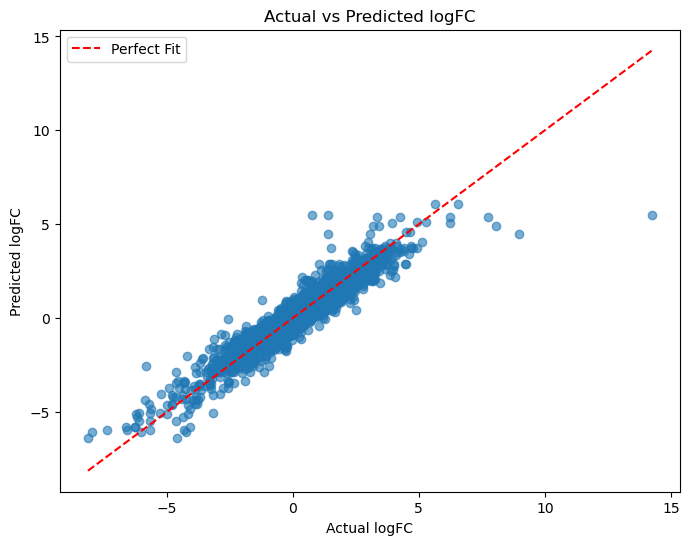

In [9]:
# Step 8: Plot actual vs predicted logFC for all SNPs
plt.figure(figsize=(8, 6))
plt.scatter(predicted_data['logFC'], predicted_data['Predicted'], alpha=0.6)
plt.plot(
    [predicted_data['logFC'].min(), predicted_data['logFC'].max()],
    [predicted_data['logFC'].min(), predicted_data['logFC'].max()],
    color='red', linestyle='--', label='Perfect Fit'
)
plt.xlabel('Actual logFC')
plt.ylabel('Predicted logFC')
plt.title('Actual vs Predicted logFC')
plt.legend()
plt.show()

In [10]:
# Step 9: Calculate and print R-squared score for all data
from statsmodels.stats.multitest import multipletests
overall_r2 = r2_score(predicted_data['logFC'], predicted_data['Predicted'])
print(f"Overall R-squared: {overall_r2}")

celltype_pvalues = []
snp_ids = []
coefficients = []
for result in results:
    pvalue = result['PValues'].get('C(CellType)[T.Immune]', None)
    if pvalue is not None:
        celltype_pvalues.append(pvalue)
        snp_ids.append(result['SNP_ID'])
        result['PValues'].get('C(CellType)[T.Immune]', None)
        coefficients.append(result['Coefficients'].get('C(CellType)[T.Immune]', None))


adjusted_pvalues = multipletests(celltype_pvalues, method='fdr_bh')[1]

# Create a DataFrame with the results
results_df = pd.DataFrame({
    'SNP_ID': snp_ids,
    'CellType_PValue': celltype_pvalues,
    'Adj_PValue': adjusted_pvalues,
    'Coefficient':coefficients
})

# Identify significant SNPs
significant_snps = results_df[results_df['Adj_PValue'] < 0.05]
results_df['Significant'] = (results_df['Adj_PValue'] < 0.05) & (abs(results_df['Coefficient']) >= 0.5)
import matplotlib.pyplot as plt
import numpy as np

# Calculate -log10 of adjusted p-values
results_df['neg_log10_Adj_PValue'] = -np.log10(results_df['Adj_PValue'])
results_df=results_df.set_index('SNP_ID')

Overall R-squared: 0.880360155565547


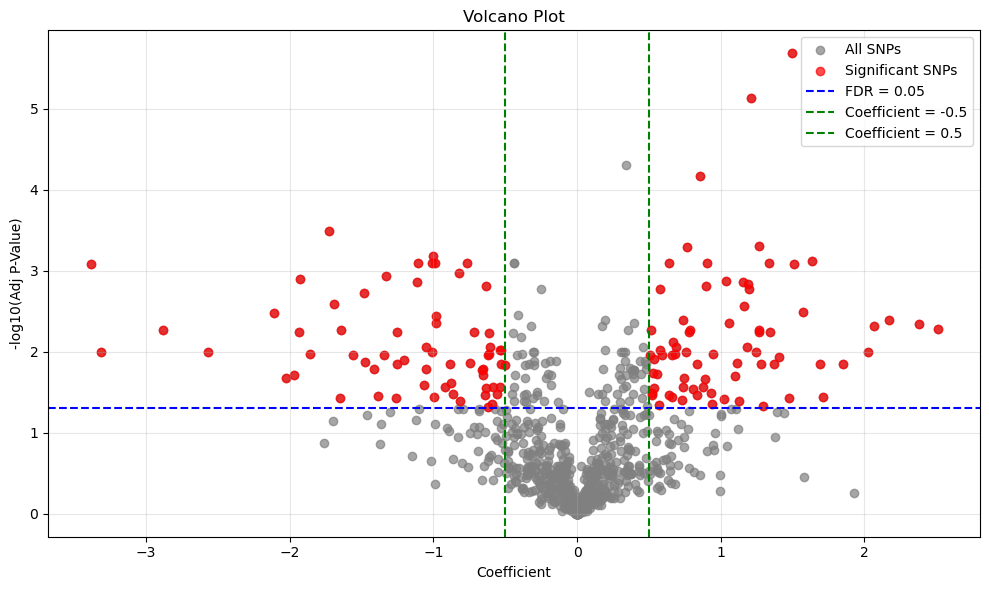

In [11]:
df = results_df
# Volcano plot
plt.figure(figsize=(10, 6))
plt.scatter(df["Coefficient"], df["neg_log10_Adj_PValue"], color="grey", alpha=0.7, label="All SNPs")

# Highlight significant points
significant = df[(df["Adj_PValue"] <= 0.05) & (abs(df["Coefficient"]) > 0.5)]
plt.scatter(significant["Coefficient"], significant["neg_log10_Adj_PValue"], color="red", alpha=0.7, label="Significant SNPs")

# Add dashed lines for thresholds
plt.axhline(-np.log10(0.05), color="blue", linestyle="--", label="FDR = 0.05")
plt.axvline(-0.5, color="green", linestyle="--", label="Coefficient = -0.5")
plt.axvline(0.5, color="green", linestyle="--", label="Coefficient = 0.5")

# Add labels and legend
plt.title("Volcano Plot")
plt.xlabel("Coefficient")
plt.ylabel("-log10(Adj P-Value)")
plt.legend()
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()


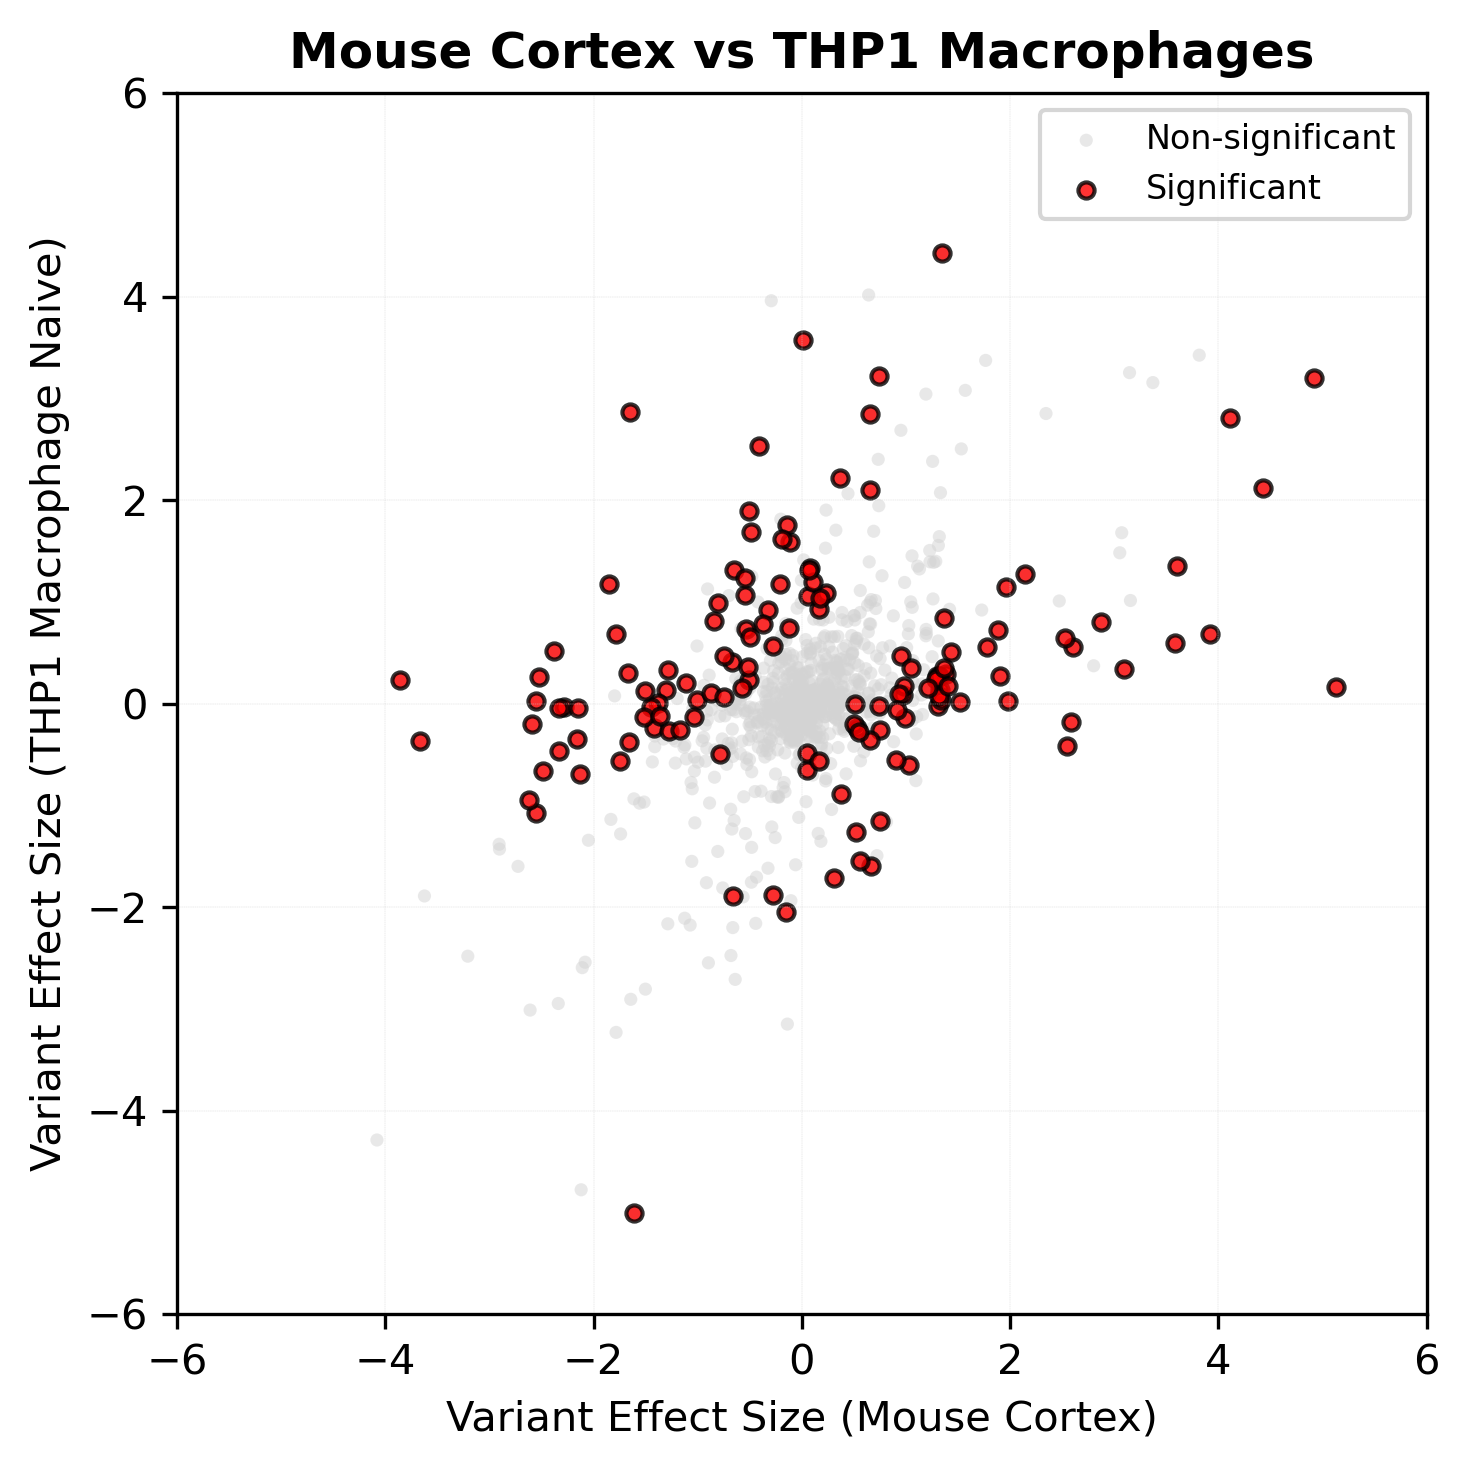

In [219]:
import matplotlib.pyplot as plt

# Merge df_cluster with results_df to include adjusted p-values and significance
df_merged = df_cluster.merge(
    results_df[['SNP_ID', 'Adj_PValue', 'Significant']],
    left_index=True, right_on='SNP_ID'
)

# Create a scatter plot with smaller dot size
plt.figure(figsize=(5, 5),dpi=300)  # Smaller figure size for a compact view

# Plot non-significant SNPs with reduced dot size
plt.scatter(
    df_merged['ML_majormino_logFC_Mouse_Cortex_AgeB-m'],
    df_merged['ML_majormino_logFC_THP1_Naive-Calvin_2'],
    alpha=0.5, c='lightgrey', label='Non-significant', edgecolor='none', s=10  # Smaller dots
)

# Highlight significant SNPs with reduced dot size
significant_points = df_merged[df_merged['Significant']]
plt.scatter(
    significant_points['ML_majormino_logFC_Mouse_Cortex_AgeB-m'],
    significant_points['ML_majormino_logFC_THP1_Naive-Calvin_2'],
    alpha=0.8, c='red', label='Significant', edgecolor='black', s=15  # Slightly larger for emphasis
)

# Add gridlines for better readability
plt.grid(color='lightgray', linestyle='--', linewidth=0.1)

# Set plot limits for better focus
plt.xlim(-6, 6)
plt.ylim(-6, 6)

# Add axis labels and title with a cleaner font style
plt.xlabel('Variant Effect Size (Mouse Cortex)', fontsize=10)
plt.ylabel('Variant Effect Size (THP1 Macrophage Naive)', fontsize=10)
plt.title('Mouse Cortex vs THP1 Macrophages', fontsize=12, weight='bold')

# Add a legend with a slightly smaller font size
plt.legend(frameon=True, fontsize=8)

# Reduce excess whitespace in the figure
plt.tight_layout()

plt.savefig('scatter_plot_MousevsTHP1.pdf', dpi=300, bbox_inches='tight')
# Display the plot
plt.show()



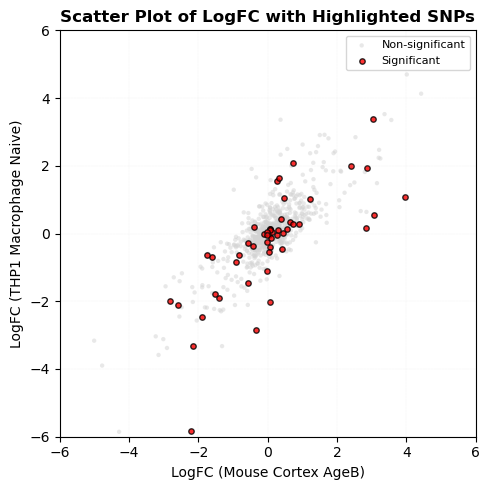

In [110]:
import matplotlib.pyplot as plt

# Merge df_cluster with results_df to include adjusted p-values and significance
df_merged = df_cluster.merge(
    results_df[['SNP_ID', 'Adj_PValue', 'Significant']],
    left_index=True, right_on='SNP_ID'
)

# Create a scatter plot with smaller dot size
plt.figure(figsize=(5, 5))  # Smaller figure size for a compact view

# Plot non-significant SNPs with reduced dot size
plt.scatter(
    df_cluster['ML_majormino_logFC_THP1_Naive-Calvin_2'],
    df_cluster['ML_majormino_logFC_THP1_LPSIFNG-Calvin'],
    alpha=0.5, c='lightgrey', label='Non-significant', edgecolor='none', s=10  # Smaller dots
)

differential_model_significant_index = df_mean_sig[abs(df_mean_sig['logFC_converted'])>=0.1].index.tolist()
# Highlight significant SNPs with reduced dot size
significant_points = df_merged[df_merged['SNP_ID'].isin(differential_model_significant_index)]
plt.scatter(
    significant_points['ML_majormino_logFC_THP1_Naive-Calvin_2'],
    significant_points['ML_majormino_logFC_THP1_LPSIFNG-Calvin'],
    alpha=0.8, c='red', label='Significant', edgecolor='black', s=15  # Slightly larger for emphasis
)

# Add gridlines for better readability
plt.grid(color='lightgray', linestyle='--', linewidth=0.1)

# Set plot limits for better focus
plt.xlim(-6, 6)
plt.ylim(-6, 6)

# Add axis labels and title with a cleaner font style
plt.xlabel('LogFC (Mouse Cortex AgeB)', fontsize=10)
plt.ylabel('LogFC (THP1 Macrophage Naive)', fontsize=10)
plt.title('Scatter Plot of LogFC with Highlighted SNPs', fontsize=12, weight='bold')

# Add a legend with a slightly smaller font size
plt.legend(frameon=True, fontsize=8)

# Reduce excess whitespace in the figure
plt.tight_layout()

# Display the plot
plt.show()



/tmp/ipykernel_224073/3517914659.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mean_sig['logFC'] = df_mean_sig['ref_atac_bayesian_mean']-df_mean_sig['alt_atac_bayesian_mean']


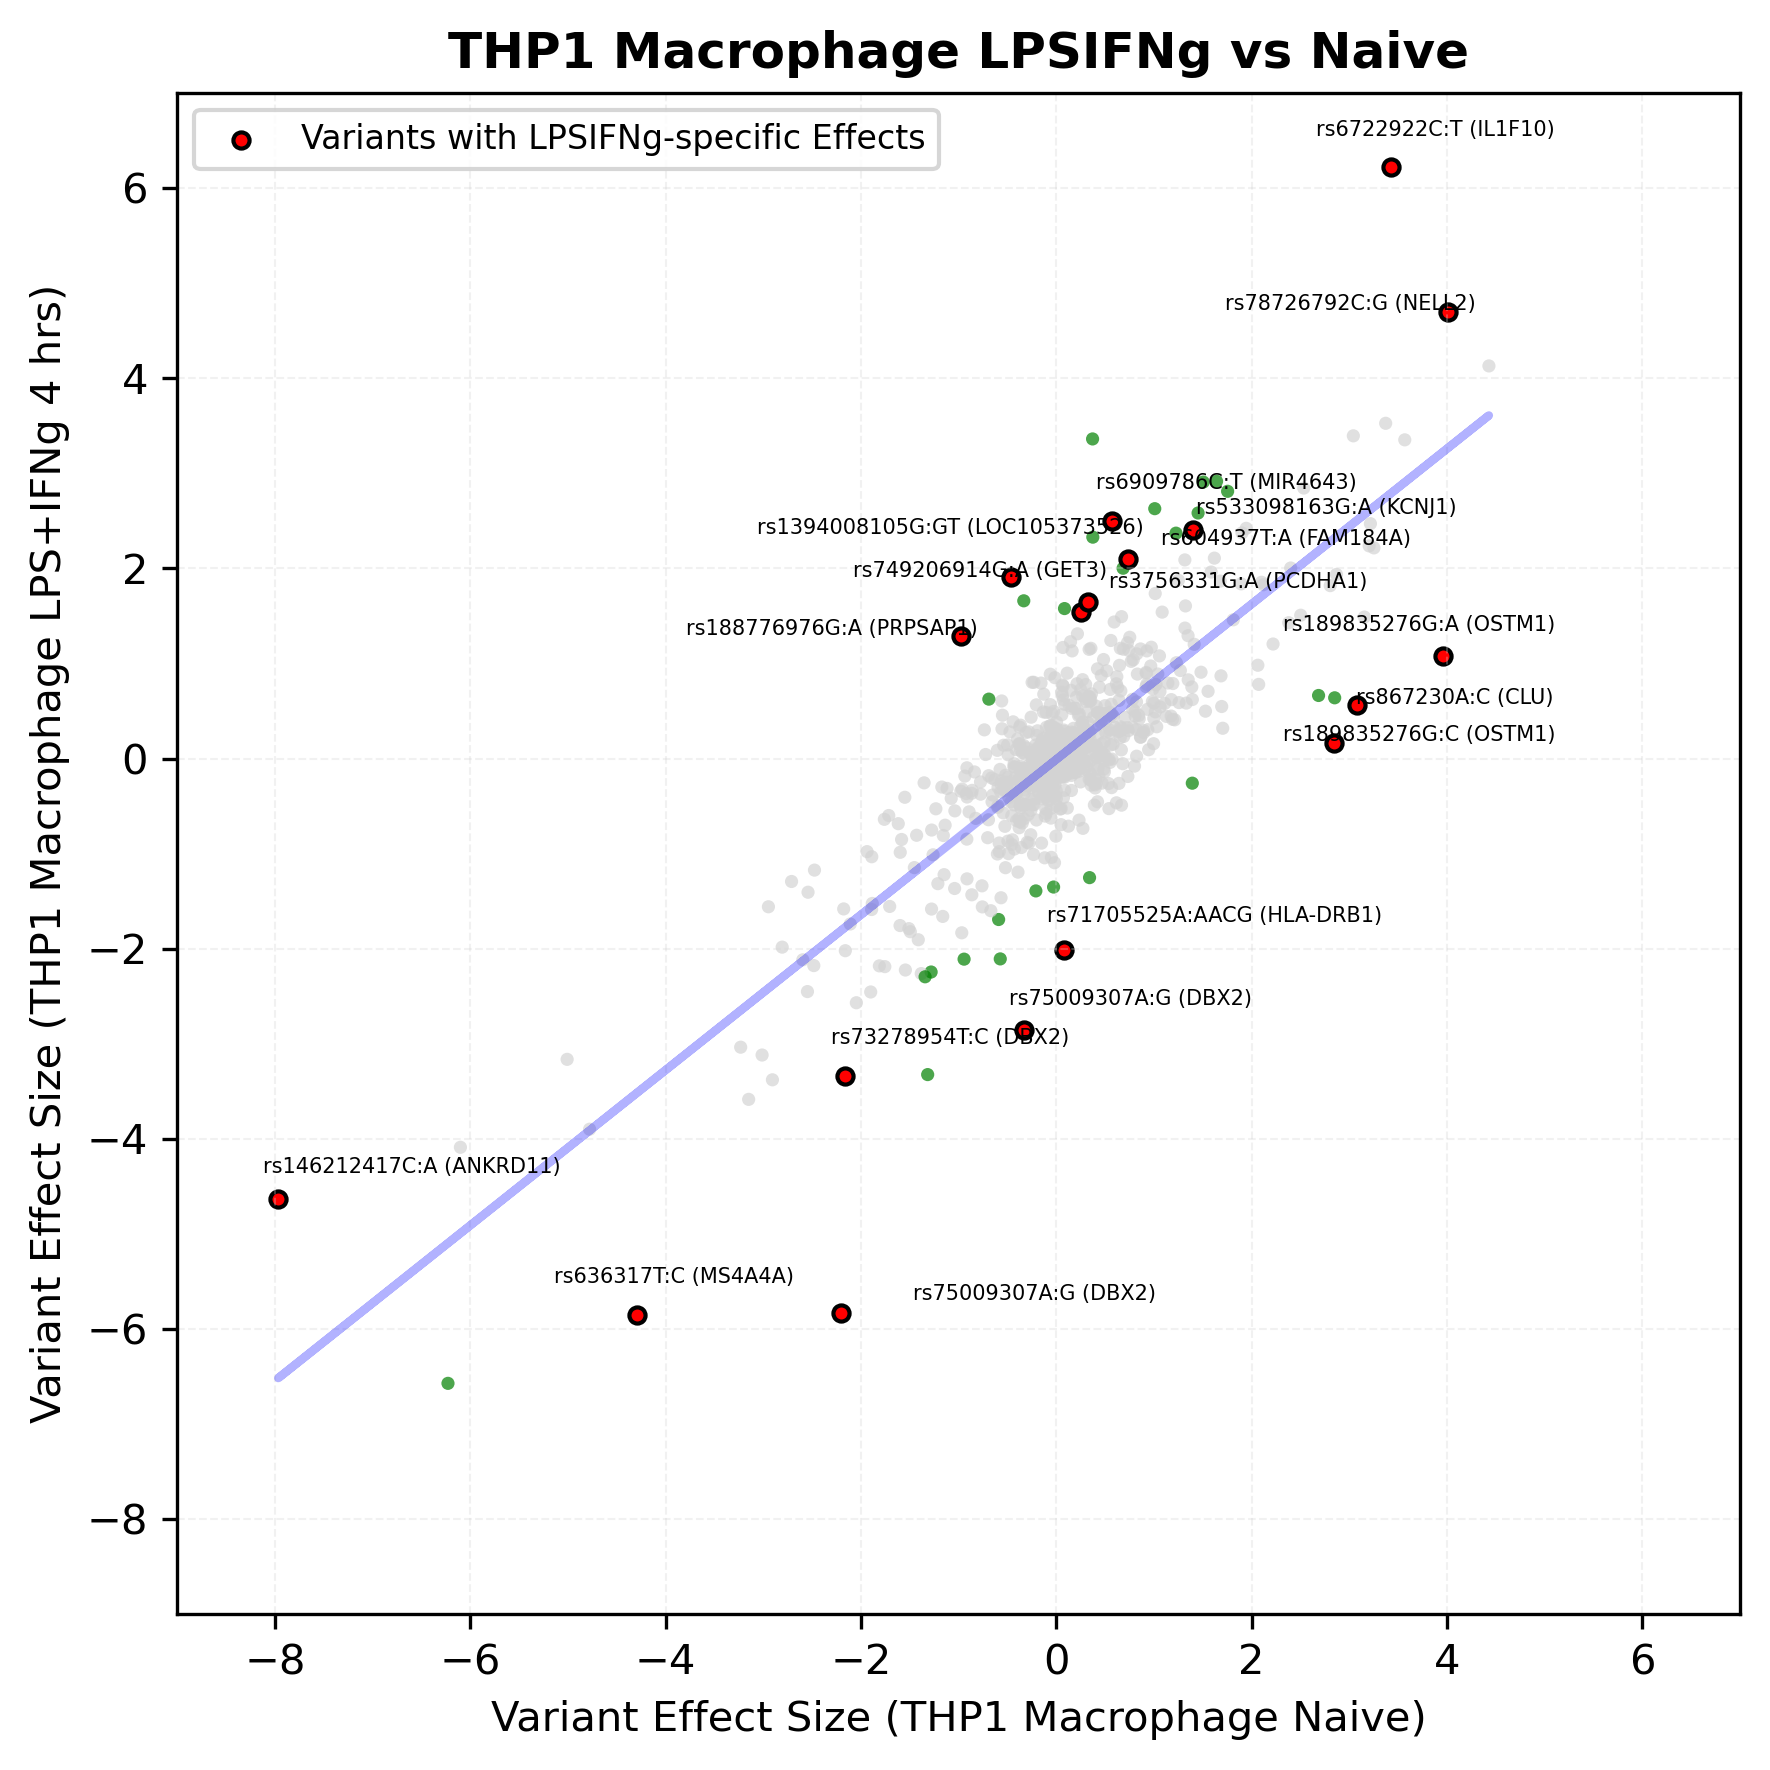

In [ ]:
import os
import pandas as pd
import pandas as pd
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests
df_mpra = pd.read_csv('indexing/MPRA3_Contributor_20231108_unique_GeneName_BarcodeEnhancerPair.csv' , index_col=0)
df_mpra_23985 = df_mpra.iloc[0:24000-15]
df_index = pd.read_csv('indexing/ALT_REF_LookUpTable_filtered_amended_alleleOnly_20240605.csv')
df_index.columns = ['alt','ref']
path = "../THP1_machinelearning/mpra3_prediction/prediction/10kbmodels_20240809_MPRA_500bp_SNPandControl_Ns_227bpbarcodes_20240825/"
df_difference = pd.DataFrame()
df_difference_statistic = pd.DataFrame()
f = 'THP1_LPSIFNGvsNaive_20241106_MPRA_500bp_SNPonly_Ns_bayesian.csv'
df = pd.read_csv(path+f,sep='\t',header=None)
df =df.iloc[0:(24000-15)*2]
data = df.values
reshaped_data = data.reshape(1599, 1920)
reshaped_df = pd.DataFrame(reshaped_data)
reshaped_df.index = df_mpra_23985['enhancer_id'].unique()
df_avg_1599 = reshaped_df
alt = df_avg_1599.loc[df_index['alt']]
ref = df_avg_1599.loc[df_index['ref']]
alt_mean = alt.mean(axis=1)
ref_mean = ref.mean(axis=1)
assert alt.shape == ref.shape, "Dataframes do not have the same shape"
p_values = []
statistic_list = []
for i in range(alt.shape[0]):
    row_alt = alt.iloc[i, :]
    row_ref = ref.iloc[i, :]
    statistic, p_value = ranksums(row_alt, row_ref, alternative='two-sided')
    p_values.append(p_value)
    statistic_list.append(statistic)

# Perform FDR correction
p_values_corrected = multipletests(p_values, alpha=0.05, method='fdr_bh')[1]

# Convert the list of corrected p-values into a DataFrame
p_values_df = pd.DataFrame({
    'p_value': p_values,
    'fdr': p_values_corrected,
    'statistics': statistic_list
})
p_values_df.index=alt.index
df_difference[f[0:19]] = p_values_df['fdr']
df_difference_statistic[f[0:19]] = p_values_df['statistics']
df_mean = pd.DataFrame([alt_mean.tolist(),ref_mean.tolist()]).T
df_mean.index=alt_mean.index
df_mean.columns = ['alt_atac_bayesian_mean','ref_atac_bayesian_mean']
df_mean['ref_name']=ref_mean.index
df_mean.head()
import numpy as np
df_mean['fdr_bayesian'] = df_difference

df_mean_sig = df_mean[(df_mean['fdr_bayesian']<=10**(-20))]
df_mean_sig['logFC'] = df_mean_sig['ref_atac_bayesian_mean']-df_mean_sig['alt_atac_bayesian_mean']
df_haploreg = pd.read_csv('indexing/SNP_haploreg_annotated_index_20240818_curated_annotated.csv',index_col=0)
df_mean_sig = pd.merge(df_mean_sig,df_haploreg,left_index=True,right_index=True)
df_mean_sig['logFC_converted'] = df_mean_sig.apply(lambda row: -row['logFC'] if row['REFALT_Flip'] else row['logFC'], axis=1)
df_mean_sig["RSID_Gene_Contributor"]=df_mean_sig["rsID"]+df_mean_sig['Major']+":"+df_mean_sig['Minor']+" ("+df_mean_sig["nearest_gene"]+")"
df_mean_sig['fdr_bayesian'].astype(np.float128)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Merge df_cluster with results_df to include adjusted p-values and significance
df_merged = df_cluster.merge(
    results_df[['SNP_ID', 'Adj_PValue', 'Significant']],
    left_index=True, right_on='SNP_ID'
)

# Define the x and y variables
x = df_cluster['ML_majormino_logFC_THP1_Naive-Calvin_2'].values.reshape(-1, 1)
y = df_cluster['ML_majormino_logFC_THP1_LPSIFNG-Calvin'].values

# Fit a linear regression model
model = LinearRegression()
model.fit(x, y)

# Predict y values based on the fitted model
y_pred = model.predict(x)

# Calculate residuals
residuals = y - y_pred

# Define outliers as points where residuals > 2 standard deviations
threshold = 2 * np.std(residuals)
outliers = np.abs(residuals) > threshold

# Add residuals and outlier information to df_cluster
df_cluster['Residual'] = residuals
df_cluster['Outlier'] = outliers

# Identify significant SNPs based on df_mean_sig
differential_model_significant_index = df_mean_sig[abs(df_mean_sig['logFC_converted']) >= 0.05].index.tolist()
significant_points = df_merged[df_merged['SNP_ID'].isin(differential_model_significant_index)]

# Categorize SNPs for coloring
colors = []
for idx, row in df_cluster.iterrows():
    if row['Outlier'] and idx in differential_model_significant_index:
        colors.append('red')  # Significant and outlier
    elif row['Outlier']:
        colors.append('green')  # Outlier but not significant
    else:
        colors.append('lightgrey')  # Neither significant nor outlier

from adjustText import adjust_text
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Plot the scatter plot with regression and labels for red dots using rsid_gene
plt.figure(figsize=(6, 6), dpi=300)
# Add gridlines for better readability
plt.grid(color='lightgray', linestyle='--', linewidth=0.5,alpha = 0.3)
# Scatter plot with custom colors
plt.scatter(
    df_cluster['ML_majormino_logFC_THP1_Naive-Calvin_2'],
    df_cluster['ML_majormino_logFC_THP1_LPSIFNG-Calvin'],
    c=colors,
    alpha=0.7,
    s=10,
    edgecolor='none',
)

# Plot the regression line
plt.plot(x, y_pred, color='blue', linewidth=2, label='', alpha=0.3)

# Highlight and label red dots with rsid_gene
red_points = df_cluster[
    (df_cluster.index.isin(differential_model_significant_index)) & (df_cluster['Outlier'])
]

plt.scatter(
    red_points['ML_majormino_logFC_THP1_Naive-Calvin_2'],
    red_points['ML_majormino_logFC_THP1_LPSIFNG-Calvin'],
    color='red',
    label='Variants with LPSIFNg-specific Effects',
    edgecolor='black',
    s=15
)

# Collect text objects for adjustment with labels positioned directly above the dots
texts = []
for idx, row in red_points.iterrows():
    texts.append(
        plt.text(
            row['ML_majormino_logFC_THP1_Naive-Calvin_2'],
            row['ML_majormino_logFC_THP1_LPSIFNG-Calvin'] + 0.2,  # Offset slightly above the dot
            row['rsid_gene'],
            fontsize=5,
            color='black',
            ha='center',
            va='bottom'
        )
    )

# Adjust text positions to avoid overlap (no arrows)
adjust_text(
    texts,
    force_text=(0.5, 0.5),   # Push texts farther from each other (x and y forces)
    force_points=(0.2, 0.2)  # Push texts farther from points (x and y forces)
)

# Set plot limits
plt.xlim(-9, 7)
plt.ylim(-9, 7)

# Add labels and title
plt.xlabel('Variant Effect Size (THP1 Macrophage Naive)', fontsize=10)
plt.ylabel('Variant Effect Size (THP1 Macrophage LPS+IFNg 4 hrs)', fontsize=10)
plt.title('THP1 Macrophage LPSIFNg vs Naive', fontsize=12, weight='bold')

# Add legend
plt.legend(loc='upper left', fontsize=8)

# Reduce excess whitespace
plt.tight_layout()

plt.savefig('scatter_plot_LPSIFNGvsNaive.pdf', dpi=300, bbox_inches='tight')
# Display the plot
plt.show()



/tmp/ipykernel_224073/2847132038.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mean_sig['logFC'] = df_mean_sig['ref_atac_bayesian_mean']-df_mean_sig['alt_atac_bayesian_mean']


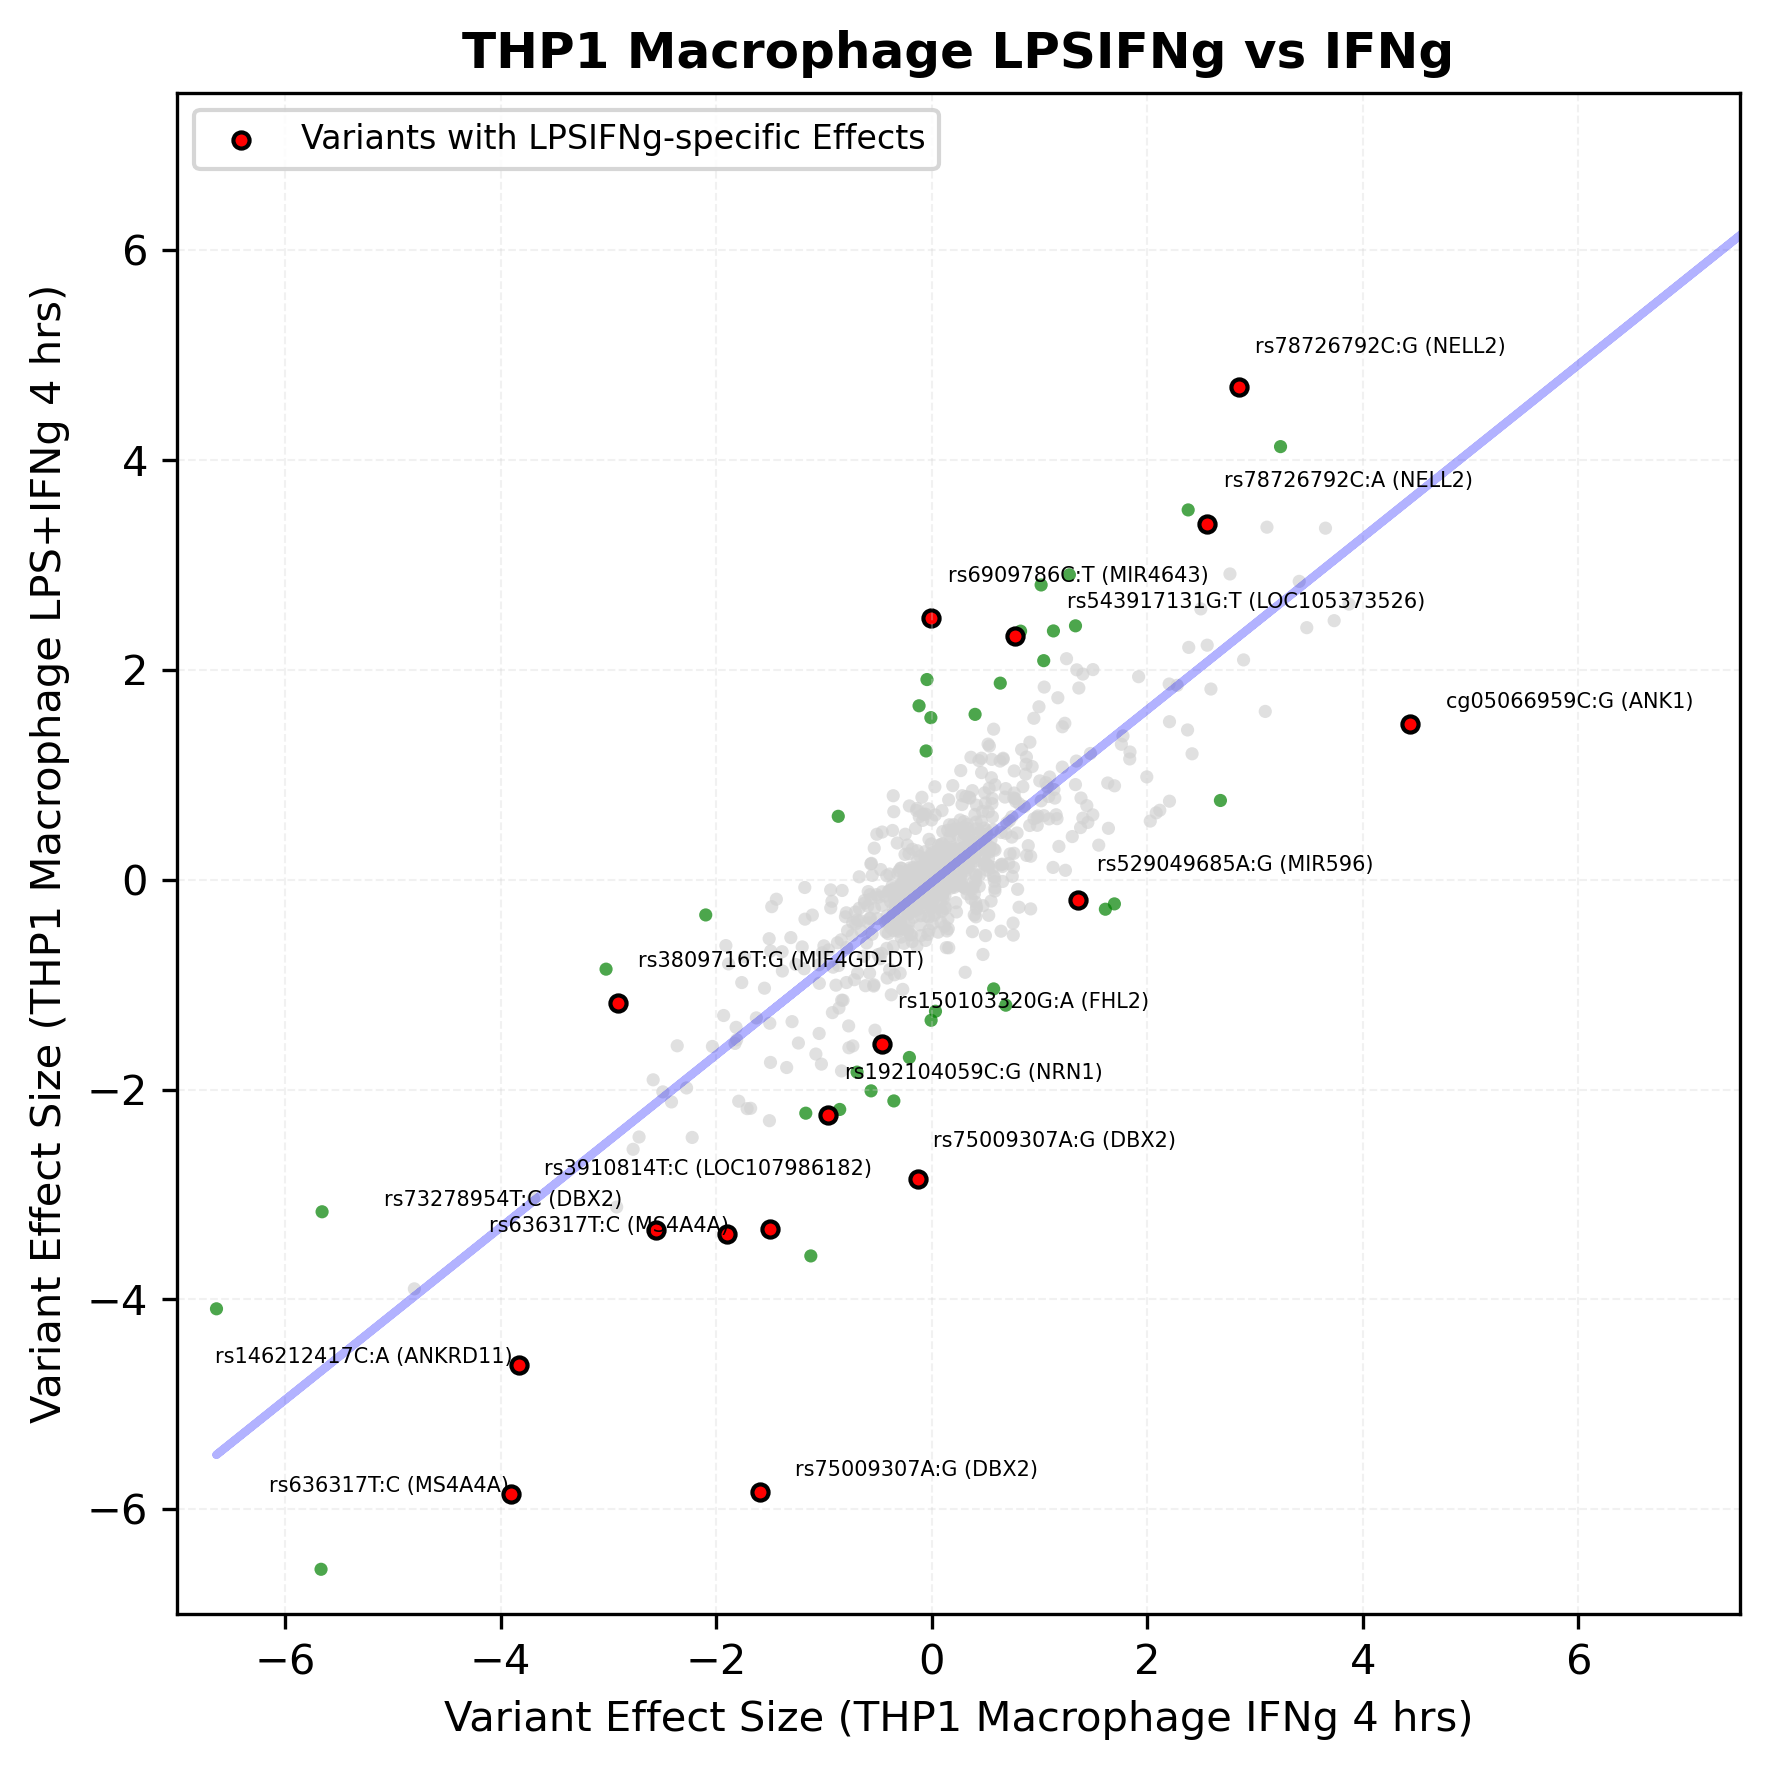

In [ ]:
import os
import pandas as pd
import pandas as pd
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests
df_mpra = pd.read_csv('indexing/MPRA3_Contributor_20231108_unique_GeneName_BarcodeEnhancerPair.csv' , index_col=0)
df_mpra_23985 = df_mpra.iloc[0:24000-15]
df_index = pd.read_csv('indexing/ALT_REF_LookUpTable_filtered_amended_alleleOnly_20240605.csv')
df_index.columns = ['alt','ref']
path = "../THP1_machinelearning/mpra3_prediction/prediction/10kbmodels_20240809_MPRA_500bp_SNPandControl_Ns_227bpbarcodes_20240825/"
df_difference = pd.DataFrame()
df_difference_statistic = pd.DataFrame()
f = 'THP1_LPSIFNGvsIFNG_20241106_MPRA_500bp_SNPonly_Ns_bayesian.csv'
df = pd.read_csv(path+f,sep='\t',header=None)
df =df.iloc[0:(24000-15)*2]
data = df.values
reshaped_data = data.reshape(1599, 1920)
reshaped_df = pd.DataFrame(reshaped_data)
reshaped_df.index = df_mpra_23985['enhancer_id'].unique()
df_avg_1599 = reshaped_df
alt = df_avg_1599.loc[df_index['alt']]
ref = df_avg_1599.loc[df_index['ref']]
alt_mean = alt.mean(axis=1)
ref_mean = ref.mean(axis=1)
assert alt.shape == ref.shape, "Dataframes do not have the same shape"
p_values = []
statistic_list = []
for i in range(alt.shape[0]):
    row_alt = alt.iloc[i, :]
    row_ref = ref.iloc[i, :]
    statistic, p_value = ranksums(row_alt, row_ref, alternative='two-sided')
    p_values.append(p_value)
    statistic_list.append(statistic)

# Perform FDR correction
p_values_corrected = multipletests(p_values, alpha=0.05, method='fdr_bh')[1]

# Convert the list of corrected p-values into a DataFrame
p_values_df = pd.DataFrame({
    'p_value': p_values,
    'fdr': p_values_corrected,
    'statistics': statistic_list
})
p_values_df.index=alt.index
df_difference[f[0:19]] = p_values_df['fdr']
df_difference_statistic[f[0:19]] = p_values_df['statistics']
df_mean = pd.DataFrame([alt_mean.tolist(),ref_mean.tolist()]).T
df_mean.index=alt_mean.index
df_mean.columns = ['alt_atac_bayesian_mean','ref_atac_bayesian_mean']
df_mean['ref_name']=ref_mean.index
df_mean.head()
import numpy as np
df_mean['fdr_bayesian'] = df_difference

df_mean_sig = df_mean[(df_mean['fdr_bayesian']<=10**(-20))]
df_mean_sig['logFC'] = df_mean_sig['ref_atac_bayesian_mean']-df_mean_sig['alt_atac_bayesian_mean']
df_haploreg = pd.read_csv('indexing/SNP_haploreg_annotated_index_20240818_curated_annotated.csv',index_col=0)
df_mean_sig = pd.merge(df_mean_sig,df_haploreg,left_index=True,right_index=True)
df_mean_sig['logFC_converted'] = df_mean_sig.apply(lambda row: -row['logFC'] if row['REFALT_Flip'] else row['logFC'], axis=1)
df_mean_sig["RSID_Gene_Contributor"]=df_mean_sig["rsID"]+df_mean_sig['Major']+":"+df_mean_sig['Minor']+" ("+df_mean_sig["nearest_gene"]+")"
df_mean_sig['fdr_bayesian'].astype(np.float128)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Merge df_cluster with results_df to include adjusted p-values and significance
df_merged = df_cluster.merge(
    results_df[['SNP_ID', 'Adj_PValue', 'Significant']],
    left_index=True, right_on='SNP_ID'
)

# Define the x and y variables
x = df_cluster['ML_majormino_logFC_THP1_IFNG-Calvin_20'].values.reshape(-1, 1)
y = df_cluster['ML_majormino_logFC_THP1_LPSIFNG-Calvin'].values

# Fit a linear regression model
model = LinearRegression()
model.fit(x, y)

# Predict y values based on the fitted model
y_pred = model.predict(x)

# Calculate residuals
residuals = y - y_pred

# Define outliers as points where residuals > 2 standard deviations
threshold = 2 * np.std(residuals)
outliers = np.abs(residuals) > threshold

# Add residuals and outlier information to df_cluster
df_cluster['Residual'] = residuals
df_cluster['Outlier'] = outliers

# Identify significant SNPs based on df_mean_sig
differential_model_significant_index = df_mean_sig[abs(df_mean_sig['logFC_converted']) >= 0.05].index.tolist()
significant_points = df_merged[df_merged['SNP_ID'].isin(differential_model_significant_index)]

# Categorize SNPs for coloring
colors = []
for idx, row in df_cluster.iterrows():
    if row['Outlier'] and idx in differential_model_significant_index:
        colors.append('red')  # Significant and outlier
    elif row['Outlier']:
        colors.append('green')  # Outlier but not significant
    else:
        colors.append('lightgrey')  # Neither significant nor outlier

from adjustText import adjust_text
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Plot the scatter plot with regression and labels for red dots using rsid_gene
plt.figure(figsize=(6, 6), dpi=300)
# Add gridlines for better readability
plt.grid(color='lightgray', linestyle='--', linewidth=0.5,alpha = 0.3)
# Scatter plot with custom colors
plt.scatter(
    df_cluster['ML_majormino_logFC_THP1_IFNG-Calvin_20'],
    df_cluster['ML_majormino_logFC_THP1_LPSIFNG-Calvin'],
    c=colors,
    alpha=0.7,
    s=10,
    edgecolor='none',
)

# Plot the regression line
plt.plot(x, y_pred, color='blue', linewidth=2, label='', alpha=0.3)

# Highlight and label red dots with rsid_gene
red_points = df_cluster[
    (df_cluster.index.isin(differential_model_significant_index)) & (df_cluster['Outlier'])
]

plt.scatter(
    red_points['ML_majormino_logFC_THP1_IFNG-Calvin_20'],
    red_points['ML_majormino_logFC_THP1_LPSIFNG-Calvin'],
    color='red',
    label='Variants with LPSIFNg-specific Effects',
    edgecolor='black',
    s=15
)

# Collect text objects for adjustment with labels positioned directly above the dots
texts = []
for idx, row in red_points.iterrows():
    texts.append(
        plt.text(
            row['ML_majormino_logFC_THP1_IFNG-Calvin_20'],
            row['ML_majormino_logFC_THP1_LPSIFNG-Calvin'] + 0.2,  # Offset slightly above the dot
            row['rsid_gene'],
            fontsize=5,
            color='black',
            ha='center',
            va='bottom'
        )
    )

# Adjust text positions to avoid overlap (no arrows)
adjust_text(
    texts,
    force_text=(0.0, 0.1),   # Push texts farther from each other (x and y forces)
    force_points=(0.2, 0.2)  # Push texts farther from points (x and y forces)
)

# Set plot limits
plt.xlim(-7, 7.5)
plt.ylim(-7, 7.5)

# Add labels and title
plt.xlabel('Variant Effect Size (THP1 Macrophage IFNg 4 hrs)', fontsize=10)
plt.ylabel('Variant Effect Size (THP1 Macrophage LPS+IFNg 4 hrs)', fontsize=10)
plt.title('THP1 Macrophage LPSIFNg vs IFNg', fontsize=12, weight='bold')

# Add legend
plt.legend(loc='upper left', fontsize=8)

# Reduce excess whitespace
plt.tight_layout()

plt.savefig('scatter_plot_LPSIFNGvsIFNG.pdf', dpi=300, bbox_inches='tight')
# Display the plot
plt.show()



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text

def plot_scatter_with_outliers(df_cluster, results_df, x_cell, y_cell, x_label, y_label, title,difference_threshold = 2, save_file=None):
    """
    Plot scatter with regression line and highlight outliers.
    
    Parameters:
    - df_cluster: DataFrame containing the data.
    - results_df: DataFrame with significance information (if needed).
    - x_cell: Column name for the x-axis.
    - y_cell: Column name for the y-axis.
    - x_label: Label for the x-axis.
    - y_label: Label for the y-axis.
    - title: Title for the plot.
    - save_file: Path to save the plot as an image (optional).
    """
    # Merge df_cluster with results_df to include adjusted p-values and significance
    df_merged = df_cluster.merge(
        results_df[['SNP_ID', 'Adj_PValue', 'Significant']],
        left_index=True, right_on='SNP_ID'
    )

    # Define the x and y variables
    x = df_cluster[x_cell].values.reshape(-1, 1)
    y = df_cluster[y_cell].values

    # Fit a linear regression model
    model = LinearRegression()
    model.fit(x, y)

    # Predict y values based on the fitted model
    y_pred = model.predict(x)

    # Calculate residuals
    residuals = y - y_pred

    # Define outliers as points where residuals > 2.5 standard deviations
    threshold = difference_threshold * np.std(residuals)
    outliers = np.abs(residuals) > threshold

    # Add residuals and outlier information to df_cluster
    df_cluster['Residual'] = residuals
    df_cluster['Outlier'] = outliers

    # Update to only consider grey and green dots (ignoring red dots/significance)
    df_cluster['Color'] = np.where(df_cluster['Outlier'], 'green', 'lightgrey')  # Green for outliers, grey for others

    # Plot the scatter plot with only grey and green dots
    plt.figure(figsize=(6, 6), dpi=300)

    # Add gridlines for better readability
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.3)

    # Scatter plot with custom colors
    plt.scatter(
        df_cluster[x_cell],
        df_cluster[y_cell],
        c=df_cluster['Color'],
        alpha=0.7,
        s=10,
        edgecolor='none',
    )

    # Plot the regression line
    plt.plot(x, y_pred, color='blue', linewidth=2, label='Regression Line', alpha=0.3)

    # Highlight green dots and collect them for labeling
    green_points = df_cluster[df_cluster['Outlier']]

    plt.scatter(
        green_points[x_cell],
        green_points[y_cell],
        color='green',
        label='Regression Outliers',
        s=10
    )

    # Add labels for green dots using 'rsid_gene'
    texts = []
    for idx, row in green_points.iterrows():
        texts.append(
            plt.text(
                row[x_cell],
                row[y_cell] + 0.2,  # Offset slightly above the dot
                row['rsid_gene'],
                fontsize=5,
                color='black',
                ha='center',
                va='bottom'
            )
        )

    # Adjust text positions to avoid overlap (no arrows)
    adjust_text(
        texts,
        force_text=(0.0, 0.1),   # Push texts farther from each other (x and y forces)
        force_points=(0.2, 0.2)  # Push texts farther from points (x and y forces)
    )

    # Add labels and title
    plt.xlabel(x_label, fontsize=10)
    plt.ylabel(y_label, fontsize=10)
    plt.title(title, fontsize=12, weight='bold')

    # Add legend
    plt.legend(loc='upper left', fontsize=8)

    # Reduce excess whitespace
    plt.tight_layout()

    # Save the plot if a file name is provided
    if save_file:
        plt.savefig(save_file, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_file}")

    # Display the plot
    plt.show()


In [ ]:
pd.read_csv("indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv", index_col=0).columns

Index(['Type', 'RSID', 'Contributor', 'nearest_gene', 'rsID', 'chr_number',
       'pos_hg38', 'r2', 'D'', 'is_query_snp',
       ...
       'variant_id', 'Bellenguez_p_value', 'Bellenguez_p_value_negLog10',
       'location', 'gene_name', 'closest_protein_coding_gene_TSS',
       'distance_to_closest_protein_coding_TSS', 'hierarchical_label',
       'rsid_gene_label', 'rsid_gene_tss'],
      dtype='object', length=170)

Plot saved to scatter_plot_IFNGvsNaive.pdf


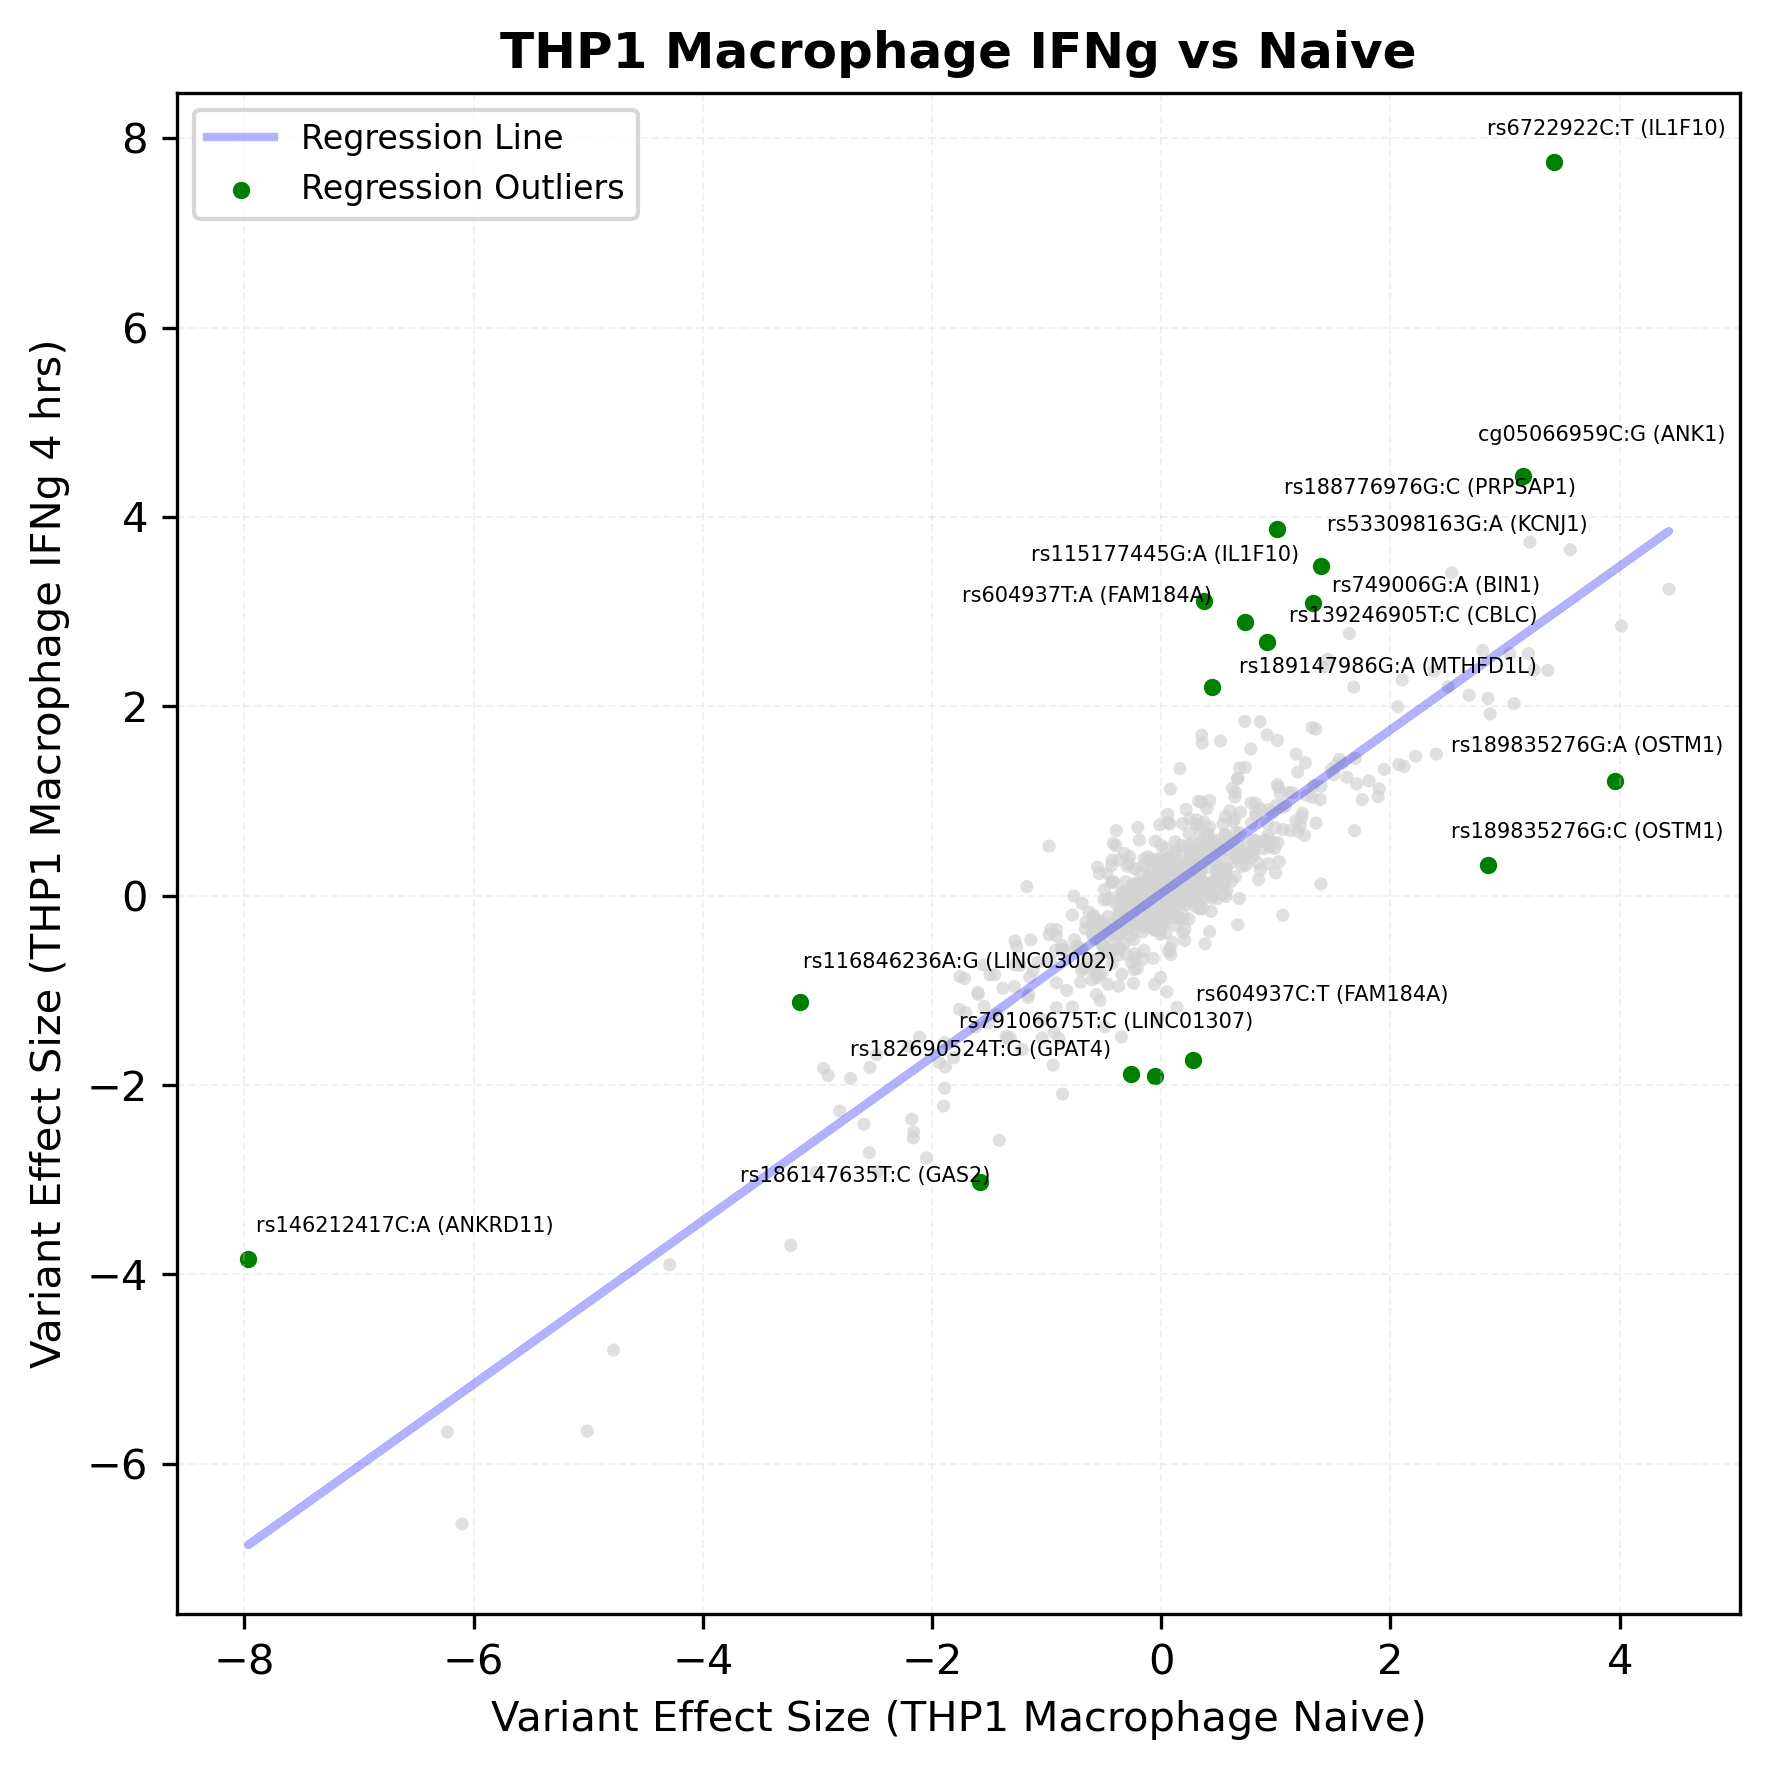

In [208]:
plot_scatter_with_outliers(
    df_cluster=df_cluster,
    results_df=results_df,
    x_cell='ML_majormino_logFC_THP1_Naive-Calvin_2',
    y_cell='ML_majormino_logFC_THP1_IFNG-Calvin_20',
    x_label='Variant Effect Size (THP1 Macrophage Naive)',
    y_label='Variant Effect Size (THP1 Macrophage IFNg 4 hrs)',
    title='THP1 Macrophage IFNg vs Naive',
    difference_threshold = 3,
    save_file='scatter_plot_IFNGvsNaive.pdf'  # Optional: Provide a path to save the plot
)


Plot saved to scatter_plot_StriatumvsCortex.pdf


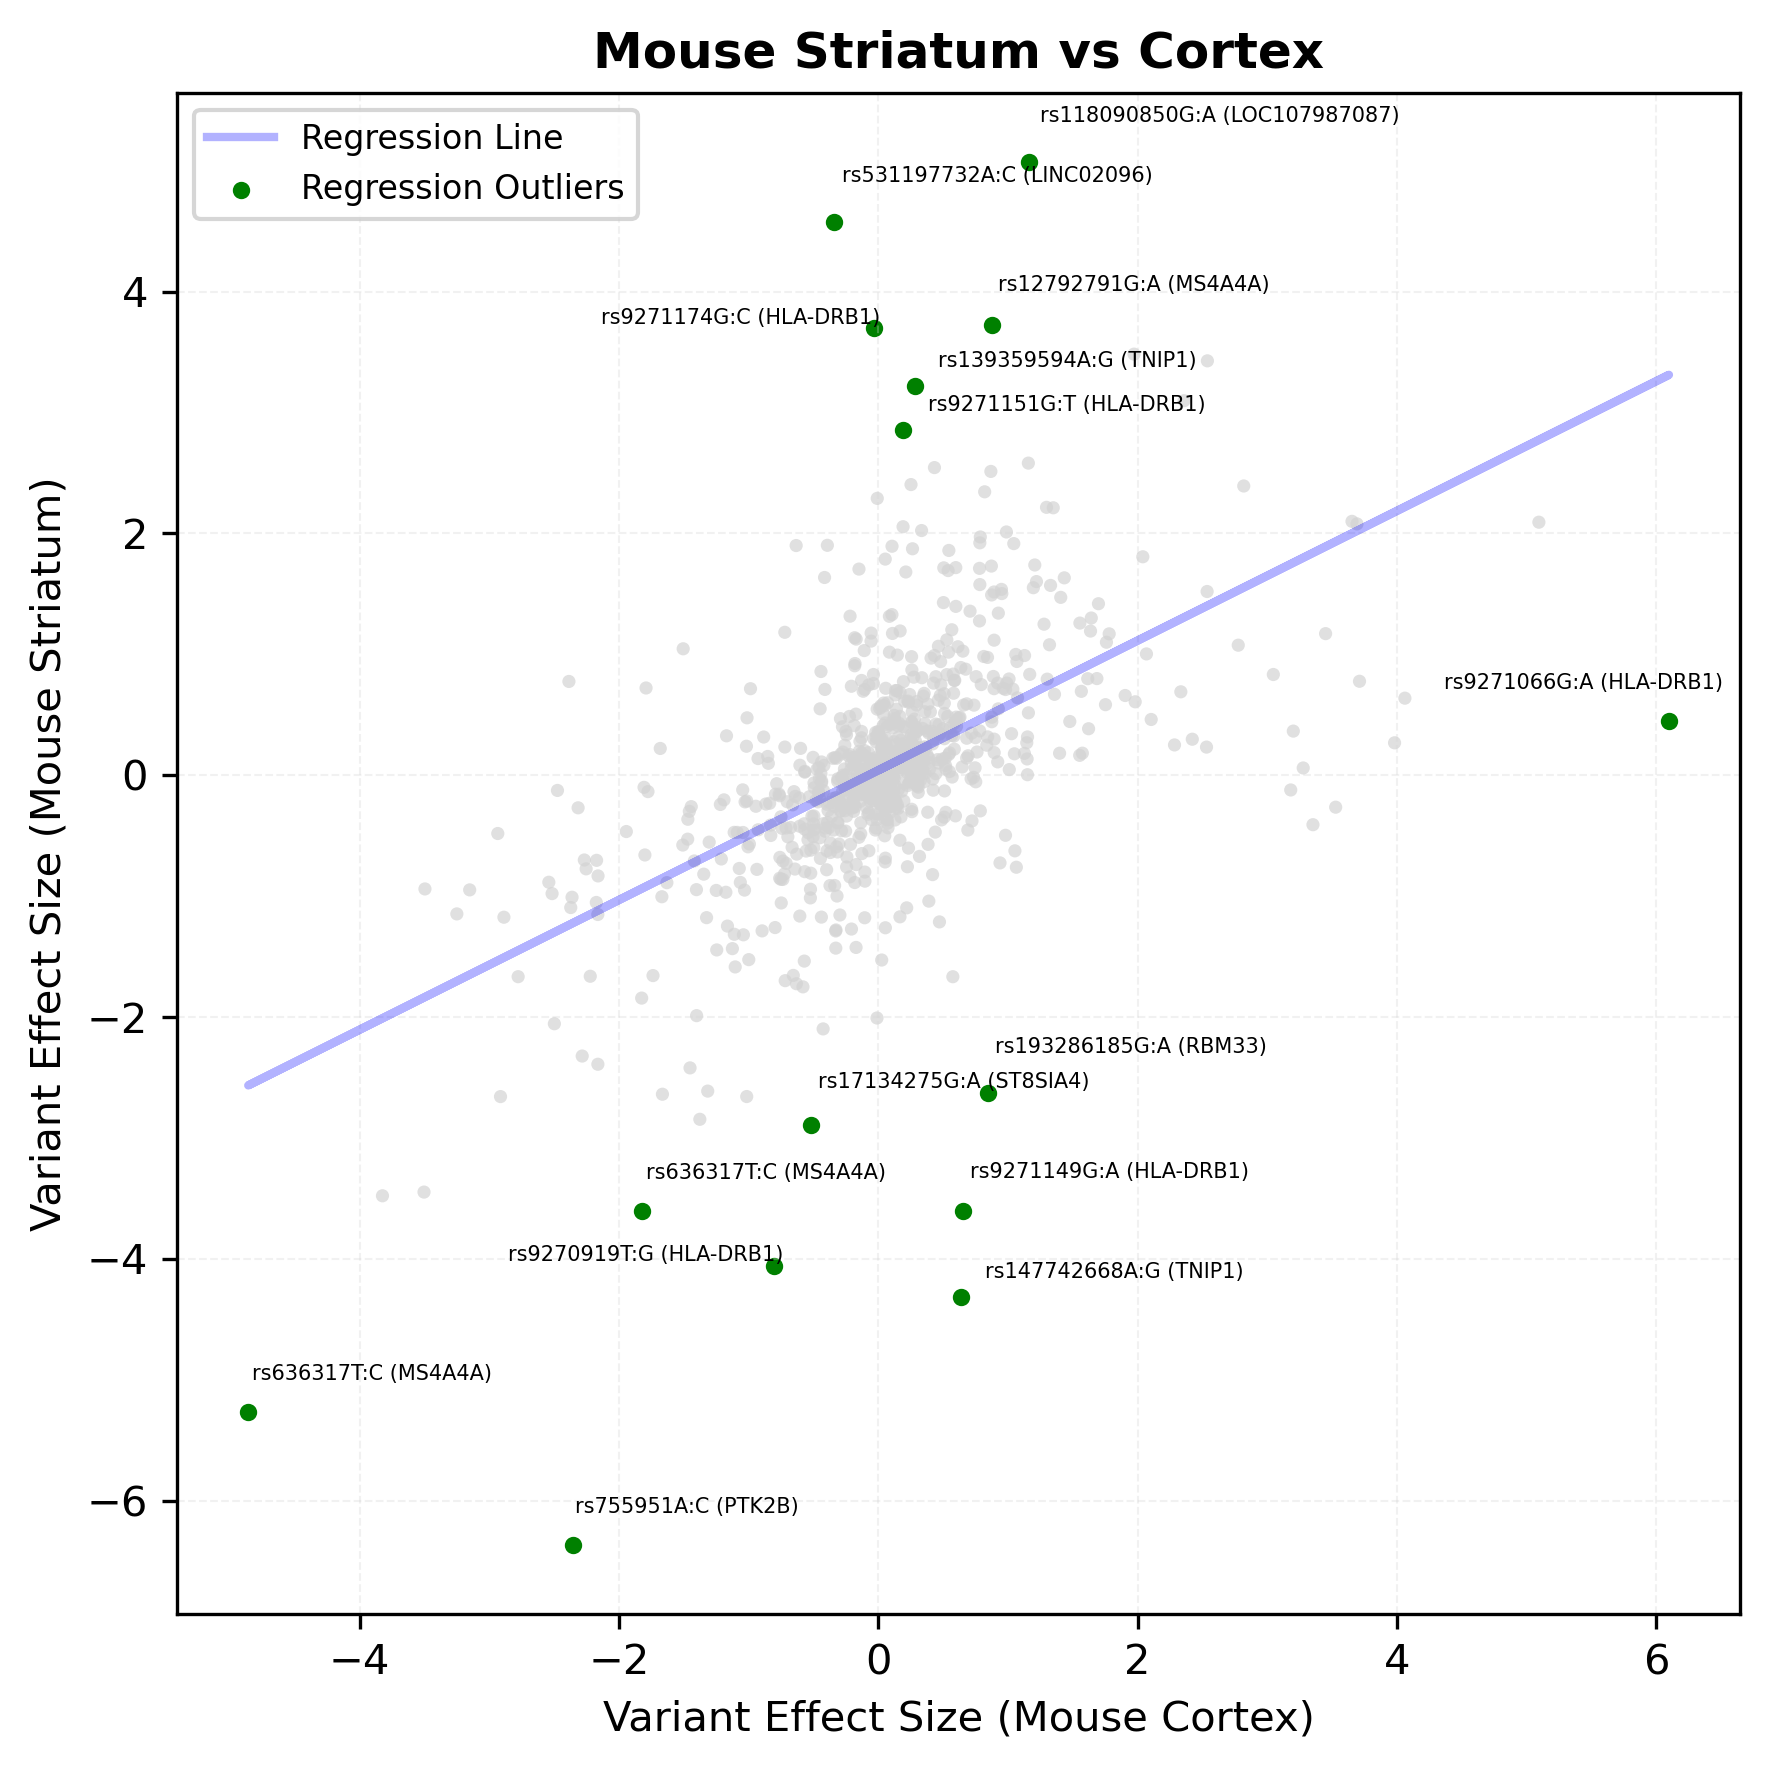

In [209]:
cortex = df_cluster[['ML_majormino_logFC_Mouse_Cortex_AgeB-m',
       'ML_majormino_logFC_Mouse_Cortex_AgeC-m']].mean(axis=1)
striatum = df_cluster[[       'ML_majormino_logFC_Mouse_Striatum_AgeB',
       'ML_majormino_logFC_Mouse_Striatum_AgeC']].mean(axis=1)
rsid_gene= df_cluster['rsid_gene']
brain = pd.DataFrame([cortex,striatum,rsid_gene]).T
brain.columns = ['Cortex','Striatum','rsid_gene']

plot_scatter_with_outliers(
    df_cluster=brain,
    results_df=results_df,
    x_cell='Cortex',
    y_cell='Striatum',
    x_label='Variant Effect Size (Mouse Cortex)',
    y_label='Variant Effect Size (Mouse Striatum)',
    title='Mouse Striatum vs Cortex',
    difference_threshold = 3,
    save_file='scatter_plot_StriatumvsCortex.pdf'  # Optional: Provide a path to save the plot
)


Plot saved to scatter_plot_IFNbvsNaive.pdf


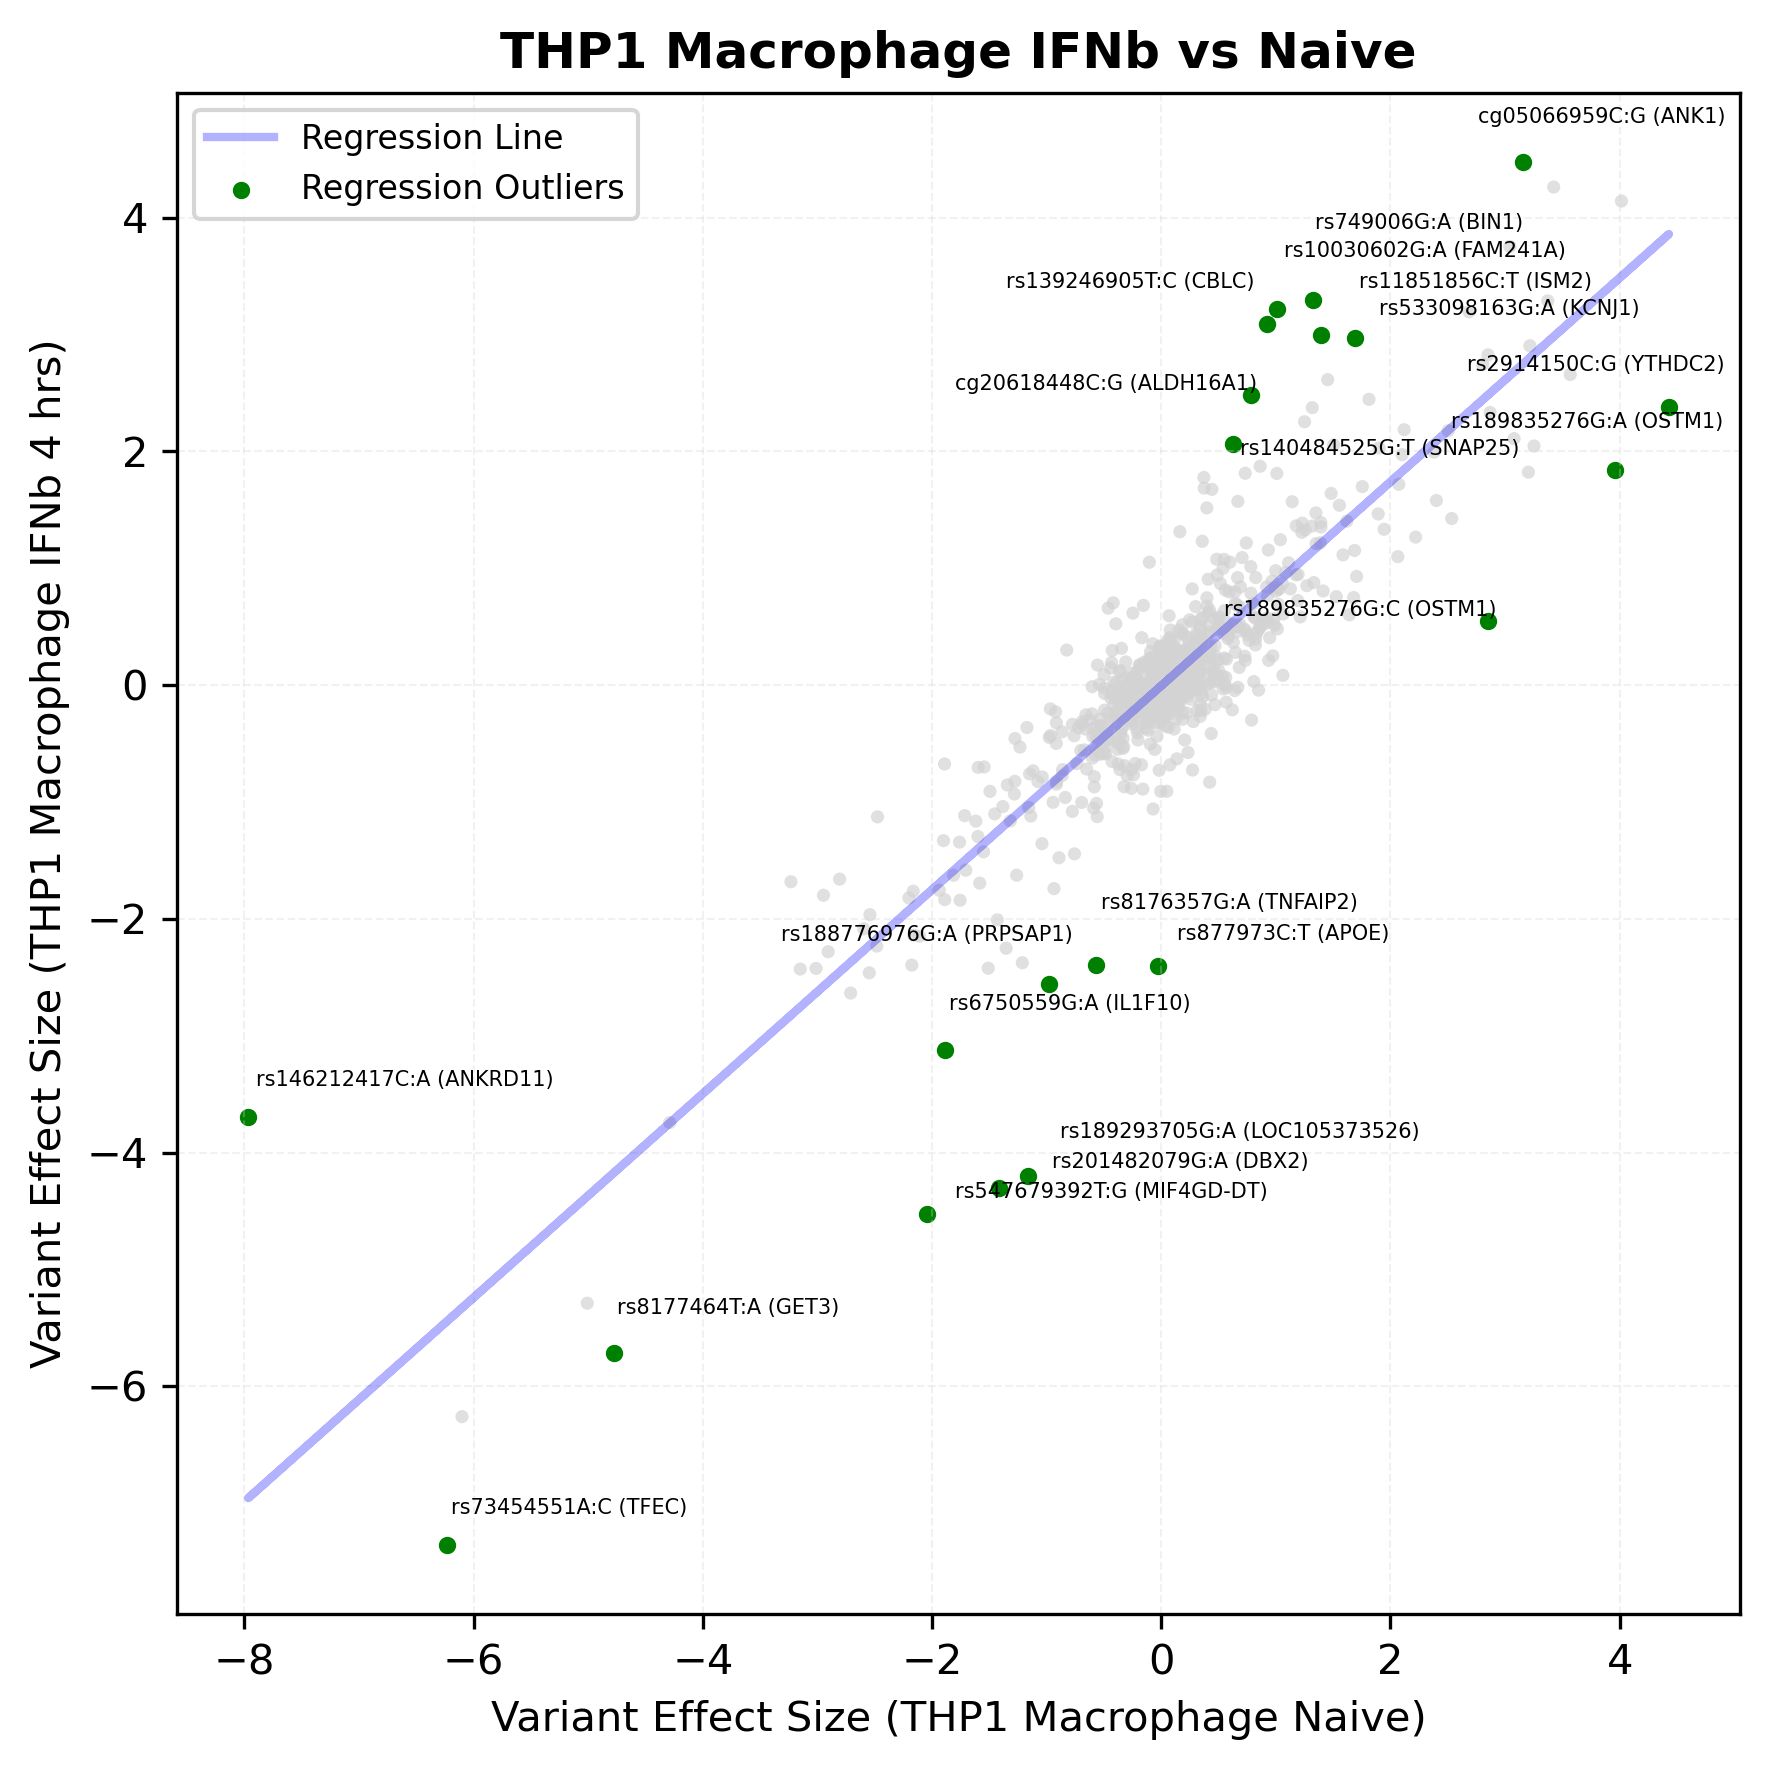

In [210]:
plot_scatter_with_outliers(
    df_cluster=df_cluster,
    results_df=results_df,
    x_cell='ML_majormino_logFC_THP1_Naive-Calvin_2',
    y_cell='ML_majormino_logFC_THP1_IFNB-Calvin_20',
    x_label='Variant Effect Size (THP1 Macrophage Naive)',
    y_label='Variant Effect Size (THP1 Macrophage IFNb 4 hrs)',
    title='THP1 Macrophage IFNb vs Naive',
    difference_threshold = 3,
    save_file='scatter_plot_IFNbvsNaive.pdf'  # Optional: Provide a path to save the plot
)
